In [1]:
import sys
from pathlib import Path

# notebook normally runs with cwd at the `analysis/` folder — add parent (project root)
project_root = Path.cwd().resolve().parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import joblib
import xgboost as xgb
import lightgbm as lgb
import optuna
from scipy.stats import randint, uniform
from datetime import timedelta
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.ensemble import RandomForestRegressor

# use absolute imports in notebook (project root was added to sys.path above)
from models.data_manipulator import INRDataManipulation
from models.training_plot import INRModelPlot
from models.training_model02 import ModelTrainer

import warnings
warnings.filterwarnings("ignore")

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


generated
1    96
0    26
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   test_date        122 non-null    datetime64[ns]
 1   dose_semanal     122 non-null    float64       
 2   inr              122 non-null    float64       
 3   inr_diff         122 non-null    float64       
 4   low_range        122 non-null    float64       
 5   high_range       122 non-null    float64       
 6   generated        122 non-null    int64         
 7   weekofyear       122 non-null    int64         
 8   month            122 non-null    int64         
 9   year             122 non-null    int64         
 10  inr_lag_1        122 non-null    float64       
 11  inr_lag_2        122 non-null    float64       
 12  inr_lag_3        122 non-null    float64       
 13  inr_lag_4        122 non-null    float64   

,test_date,dose_semanal,inr,inr_diff,low_range,high_range,generated,weekofyear,month,year,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,2022-09-13,95.0,2.571,-0.151,2.5,3.5,1,37,9,2022,2.722,2.874,2.090,2.750,2.7980,2.60900
1,2022-09-20,95.0,2.420,-0.151,2.5,3.5,0,38,9,2022,2.571,2.722,2.874,2.090,2.6465,2.56425
2,2022-09-27,95.0,2.220,-0.200,2.5,3.5,1,39,9,2022,2.420,2.571,2.722,2.874,2.4955,2.64675
3,2022-10-04,95.0,2.020,-0.200,2.5,3.5,0,40,10,2022,2.220,2.420,2.571,2.722,2.3200,2.48325
4,2022-10-11,95.0,2.225,0.205,2.5,3.5,1,41,10,2022,2.020,2.220,2.420,2.571,2.1200,2.30775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,2024-12-10,100.0,2.752,0.008,2.5,3.5,1,50,12,2024,2.745,2.737,2.730,2.722,2.7410,2.73350
118,2024-12-17,100.0,2.760,0.008,2.5,3.5,0,51,12,2024,2.752,2.745,2.737,2.730,2.7485,2.74100
119,2024-12-24,100.0,2.719,-0.041,2.5,3.5,1,52,12,2024,2.760,2.752,2.745,2.737,2.7560,2.74850
120,2024-12-31,100.0,2.679,-0.041,2.5,3.5,1,1,12,2024,2.719,2.760,2.752,2.745,2.7395,2.74400


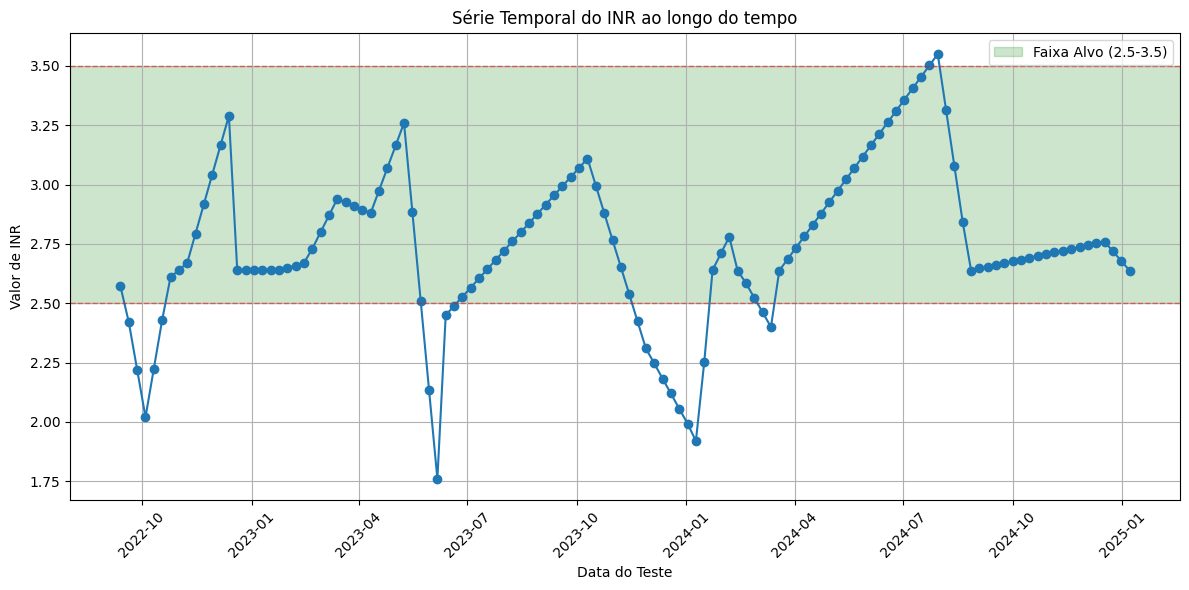

In [2]:
path = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ALINE GOMES DE FREITAS RICARDO.xlsx"

diag = INRModelPlot()

paciente = INRDataManipulation(path=path)

data = paciente.get_data_final()

print(data['generated'].value_counts())
print(data.info())

display(data)

paciente.plot_inr()

## Predição de INR

In [ ]:
_, features = paciente.get_features()
print("Features a serem analisadas:", features)

TARGET_COL = "inr"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X = data[features].copy()
y = data[TARGET_COL].copy()

display(X.head())
print(X.info())
print(y.head())
print(y.info())

# Separação treino/teste 
n_total = len(data)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
dates_train = data[DATE_COL].iloc[:n_train]
dates_test = data[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals = data['low_range'].iloc[n_train:].values
high_vals = data['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train)}, test={len(X_test)}")

,dose_semanal,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,95.0,1,37,9,2.722,2.874,2.090,2.750,2.7980,2.60900
1,95.0,0,38,9,2.571,2.722,2.874,2.090,2.6465,2.56425
2,95.0,1,39,9,2.420,2.571,2.722,2.874,2.4955,2.64675
3,95.0,0,40,10,2.220,2.420,2.571,2.722,2.3200,2.48325
4,95.0,1,41,10,2.020,2.220,2.420,2.571,2.1200,2.30775


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   dose_semanal     122 non-null    float64
 1   generated        122 non-null    int64  
 2   weekofyear       122 non-null    int64  
 3   month            122 non-null    int64  
 4   inr_lag_1        122 non-null    float64
 5   inr_lag_2        122 non-null    float64
 6   inr_lag_3        122 non-null    float64
 7   inr_lag_4        122 non-null    float64
 8   inr_roll_mean_2  122 non-null    float64
 9   inr_roll_mean_4  122 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 9.7 KB
None
0    2.571
1    2.420
2    2.220
3    2.020
4    2.225
Name: inr, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 122 entries, 0 to 121
Series name: inr
Non-Null Count  Dtype  
--------------  -----  
122 non-null    float64
dtypes: float64(1)
memory usage: 1.1 KB
None
Obs

In [ ]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

✅ ModelTrainer Inicializado
📊 Shape X_train: (98, 10)
📊 Shape y_train: (98,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42



[I 2026-02-13 03:24:04,729] A new study created in memory with name: xgboost_optimization



🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE

🚀 INICIANDO TREINAMENTO DE TODOS OS MODELOS
Modelos a treinar: ['xgboost', 'lightgbm', 'randomforest', 'elasticnet']
Total de trials: 340

🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: Sem limite segundos



Best trial: 0. Best value: -0.300972:   1%|          | 1/100 [00:03<06:22,  3.86s/it]

[I 2026-02-13 03:24:08,590] Trial 0 finished with value: -0.3009722876175487 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -0.3009722876175487.


Best trial: 1. Best value: -0.251383:   2%|▏         | 2/100 [00:07<05:45,  3.52s/it]

...

[I 2026-02-13 03:29:00,536] Trial 37 finished with value: -0.1281795188125841 and parameters: {'alpha': 6.085962510350643e-05, 'l1_ratio': 0.04956154400722146, 'tol': 0.00022285399264454, 'selection': 'cyclic'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:00,539] Trial 40 finished with value: -0.1530162964555667 and parameters: {'alpha': 0.08231376633040781, 'l1_ratio': 0.6194239330658668, 'tol': 6.492209288163312e-05, 'selection': 'cyclic'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:00,753] Trial 41 finished with value: -0.12753821625548556 and parameters: {'alpha': 0.001960349250018844, 'l1_ratio': 0.7908776369086092, 'tol': 1.01516689455291e-05, 'selection': 'cyclic'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:00,816] Trial 43 finished with value: -0.12760205549416045 and parameters: {'alpha': 0.0011898509454420381, 'l1_ratio': 0.8378552596600719, 'tol': 1.8865624237649503e-05, 'selection': 'cyclic'}. 

Best trial: 31. Best value: -0.126752:  78%|███████▊  | 47/60 [00:03<00:00, 18.94it/s]

[I 2026-02-13 03:29:00,835] Trial 44 finished with value: -0.12711127309788808 and parameters: {'alpha': 0.004340258352064828, 'l1_ratio': 0.8692050186503477, 'tol': 2.300762001633863e-05, 'selection': 'cyclic'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:00,863] Trial 45 finished with value: -0.1273569200695414 and parameters: {'alpha': 0.0023447572926710253, 'l1_ratio': 0.9362186840465543, 'tol': 2.3579435485445155e-05, 'selection': 'cyclic'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:00,917] Trial 46 finished with value: -0.12741814431488838 and parameters: {'alpha': 0.014380698768237611, 'l1_ratio': 0.605418614881715, 'tol': 0.0002444631876300991, 'selection': 'random'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:01,010] Trial 47 finished with value: -0.12754476825571415 and parameters: {'alpha': 0.011650203316289014, 'l1_ratio': 0.584467680521079, 'tol': 0.0002515970110800077, 'selection': 'random'}.

Best trial: 31. Best value: -0.126752: 100%|██████████| 60/60 [00:03<00:00, 18.02it/s]


[I 2026-02-13 03:29:01,031] Trial 48 finished with value: -0.30044594267687424 and parameters: {'alpha': 1.03547834777581, 'l1_ratio': 0.9381582032791541, 'tol': 5.5986569964479295e-05, 'selection': 'cyclic'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:01,079] Trial 50 finished with value: -0.12788554996965182 and parameters: {'alpha': 0.004908265914904055, 'l1_ratio': 0.4533360916774424, 'tol': 1.27553986508704e-05, 'selection': 'random'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:01,101] Trial 49 finished with value: -0.16057709211642776 and parameters: {'alpha': 0.0707314230386896, 'l1_ratio': 0.9287652270397253, 'tol': 2.1006404229467304e-05, 'selection': 'random'}. Best is trial 31 with value: -0.1267516094363583.
[I 2026-02-13 03:29:01,204] Trial 52 finished with value: -0.15128758171592718 and parameters: {'alpha': 0.05710876987993808, 'l1_ratio': 0.9401165972959031, 'tol': 1.1242432420560686e-05, 'selection': 'random'}. Bes

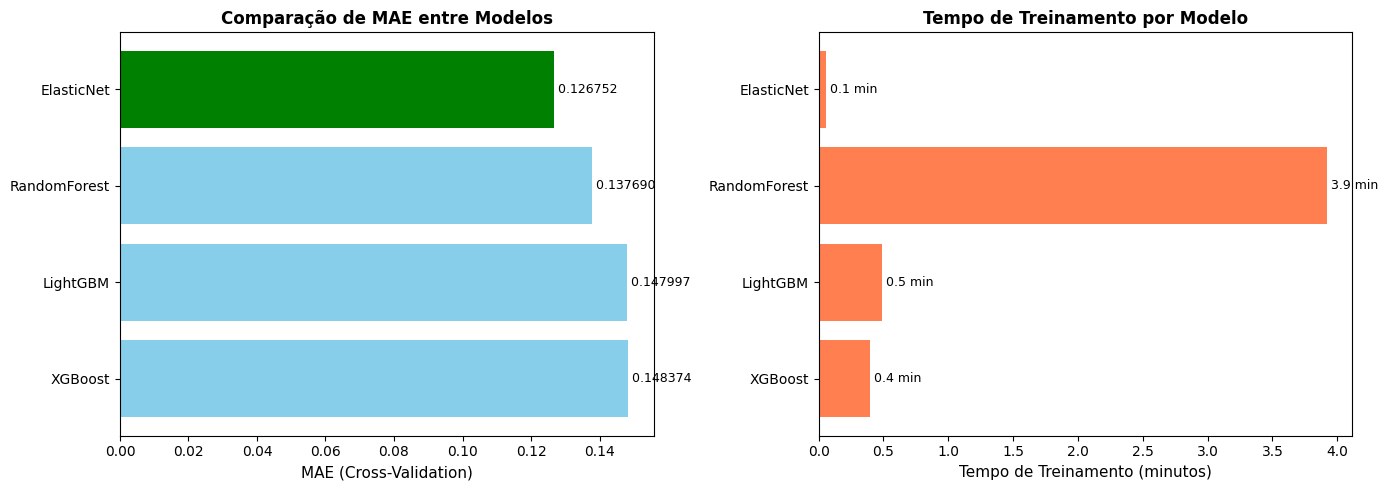

In [ ]:
# ========================================================================
# TREINAR TODOS OS MODELOS DE UMA VEZ
# ========================================================================

print("\n" + "="*70)
print("🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE")
print("="*70)

results = trainer.train_all_models(
    n_trials_dict={
        'xgboost': 100,
        'lightgbm': 100,
        'randomforest': 80,
        'elasticnet': 60
    },
    timeout=None,  # Sem timeout global
    plot_individual=False  # Não plotar cada modelo individualmente
)

# Acessar resultados
xgb_params, xgb_model, xgb_study = results['XGBoost']
lgb_params, lgb_model, lgb_study = results['LightGBM']
rf_params, rf_model, rf_study = results['RandomForest']
elastic_params, elastic_model, elastic_study, elastic_scaler = results['ElasticNet']


🏆 COMPARAÇÃO DE TODOS OS MODELOS

Modelo          MAE (CV)     Tempo (min)  Trials     Data/Hora           
------------------------------------------------------------------------------------------
ElasticNet      0.126752     0.06         60/60      2026-02-13 03:29:01 
RandomForest    0.137690     3.92         80/80      2026-02-13 03:28:55 
LightGBM        0.147997     0.49         100/100     2026-02-13 03:24:58 
XGBoost         0.148374     0.39         100/100     2026-02-13 03:24:28 
------------------------------------------------------------------------------------------

🥇 MELHOR MODELO: ElasticNet
📊 MAE (CV): 0.126752
⏱️ Tempo de treinamento: 0.06 minutos
📈 Melhoria sobre 2º lugar (RandomForest): 7.94%



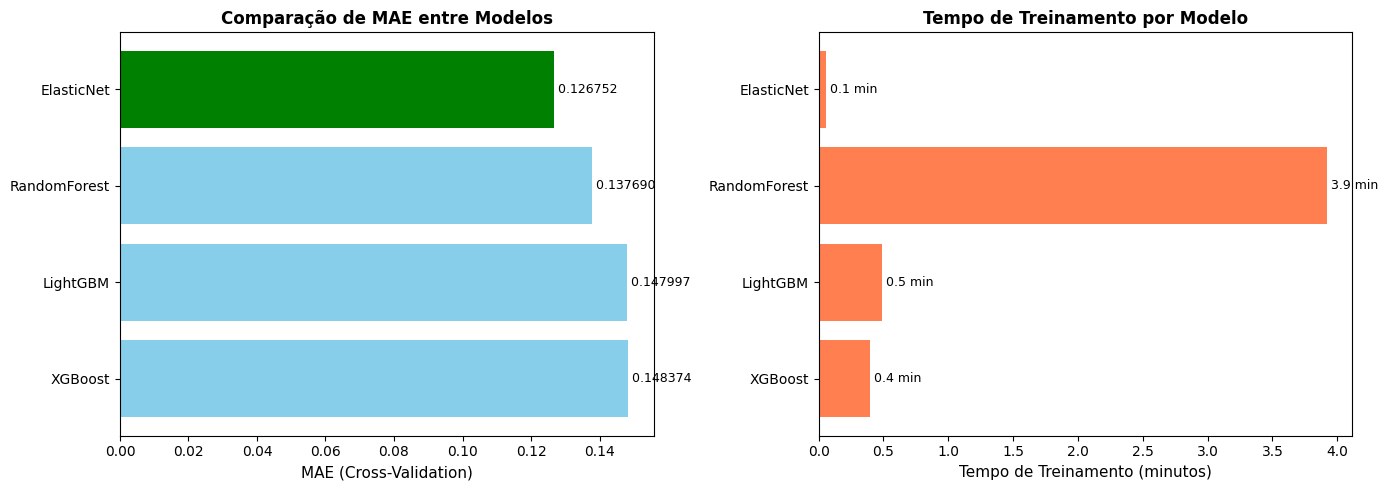


📋 Histórico completo:
     model_name                  timestamp  \
3    ElasticNet 2026-02-13 03:29:01.682639   
2  RandomForest 2026-02-13 03:28:55.679552   
1      LightGBM 2026-02-13 03:24:58.641368   
0       XGBoost 2026-02-13 03:24:28.648374   

                                         best_params  best_cv_mae  \
3  {'alpha': 0.012953943059711611, 'l1_ratio': 0....     0.126752   
2  {'n_estimators': 450, 'max_depth': 15, 'max_fe...     0.137690   
1  {'n_estimators': 1000, 'learning_rate': 0.0222...     0.147997   
0  {'n_estimators': 1900, 'max_depth': 3, 'learni...     0.148374   

   training_time_minutes  n_trials  n_completed_trials  n_pruned_trials  
3               0.055595        60                  60                0  
2               3.919658        80                  80                0  
1               0.486098       100                 100                0  
0               0.394873       100                 100                0  

📋 RESUMO DETALHADO DE TREINAM

In [ ]:
# ========================================================================
# ANÁLISES E COMPARAÇÕES
# ========================================================================

# --- Comparar todos os modelos ---
trainer.compare_all_models()

# --- Ver histórico completo ---
history_df = trainer.get_training_history()
print("\n📋 Histórico completo:")
print(history_df)

# --- Resumo detalhado ---
trainer.print_training_summary()

# --- Obter melhor modelo ---
best_name, best_model, best_params, best_mae = trainer.get_best_model()
print(f"\n🏆 Melhor modelo: {best_name}")
print(f"📊 MAE (CV): {best_mae:.6f}")
print(f"🎯 Parâmetros: {best_params}")

## Predição de Dose Semanal

In [3]:
features, _ = paciente.get_features()
print("Features a serem analisadas:", features)

TARGET_COL = "dose_semanal"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X = data[features].copy()
y = data[TARGET_COL].copy()

display(X.head())
print(X.info())
print(y.head())
print(y.info())

# Separação treino/teste 
n_total = len(data)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y.iloc[:n_train], y.iloc[n_train:]
dates_train = data[DATE_COL].iloc[:n_train]
dates_test = data[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals = data['low_range'].iloc[n_train:].values
high_vals = data['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train)}, test={len(X_test)}")

Features a serem analisadas: ['inr', 'generated', 'weekofyear', 'month', 'inr_lag_1', 'inr_lag_2', 'inr_lag_3', 'inr_lag_4', 'inr_roll_mean_2', 'inr_roll_mean_4']


,inr,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,2.571,1,37,9,2.722,2.874,2.090,2.750,2.7980,2.60900
1,2.420,0,38,9,2.571,2.722,2.874,2.090,2.6465,2.56425
2,2.220,1,39,9,2.420,2.571,2.722,2.874,2.4955,2.64675
3,2.020,0,40,10,2.220,2.420,2.571,2.722,2.3200,2.48325
4,2.225,1,41,10,2.020,2.220,2.420,2.571,2.1200,2.30775


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inr              122 non-null    float64
 1   generated        122 non-null    int64  
 2   weekofyear       122 non-null    int64  
 3   month            122 non-null    int64  
 4   inr_lag_1        122 non-null    float64
 5   inr_lag_2        122 non-null    float64
 6   inr_lag_3        122 non-null    float64
 7   inr_lag_4        122 non-null    float64
 8   inr_roll_mean_2  122 non-null    float64
 9   inr_roll_mean_4  122 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 9.7 KB
None
0    95.0
1    95.0
2    95.0
3    95.0
4    95.0
Name: dose_semanal, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 122 entries, 0 to 121
Series name: dose_semanal
Non-Null Count  Dtype  
--------------  -----  
122 non-null    float64
dtypes: float64(1)
memory usage: 1.

In [4]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

print("=" * 80)
print("🏗️ INICIALIZANDO MODELTRAINER")
print("=" * 80)

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

🏗️ INICIALIZANDO MODELTRAINER
✅ ModelTrainer Inicializado (Versão Corrigida)
📊 Shape X_train: (98, 10)
📊 Shape y_train: (98,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42



[I 2026-02-13 09:18:06,554] A new study created in memory with name: xgboost_optimization



🚀 TREINAMENTO XGBOOST
🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: 3600 segundos



Best trial: 0. Best value: -1.49335:   1%|          | 1/100 [00:03<05:26,  3.30s/it, 3.30/3600 seconds]

[I 2026-02-13 09:18:09,856] Trial 0 finished with value: -1.4933453834258152 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -1.4933453834258152.


Best trial: 1. Best value: -0.960402:   2%|▏         | 2/100 [00:05<04:35,  2.81s/it, 5.76/3600 seconds]

...

[I 2026-02-13 09:18:23,246] Trial 92 finished with value: -1.0104427740784927 and parameters: {'n_estimators': 400, 'max_depth': 9, 'learning_rate': 0.07139862060106987, 'min_child_weight': 1, 'subsample': 0.6456330405615379, 'colsample_bytree': 0.6444731248994946, 'colsample_bylevel': 0.6522213804452033, 'gamma': 3.6767031489407866, 'reg_alpha': 1.3919696406996669e-05, 'reg_lambda': 1.5334257263863505e-06, 'max_delta_step': 2, 'scale_pos_weight': 0.8681865452636652}. Best is trial 90 with value: -0.8138925598058532.
[I 2026-02-13 09:18:23,308] Trial 93 finished with value: -1.1630293280313584 and parameters: {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.05203490108334311, 'min_child_weight': 3, 'subsample': 0.9823036035370364, 'colsample_bytree': 0.9328512559269232, 'colsample_bylevel': 0.7829760226165647, 'gamma': 0.2570223296355515, 'reg_alpha': 2.1446391097479168e-05, 'reg_lambda': 0.9539456767518236, 'max_delta_step': 2, 'scale_pos_weight': 0.9003510378620088}. Best is

Best trial: 90. Best value: -0.813893:  98%|█████████▊| 98/100 [00:17<00:00, 12.45it/s, 17.06/3600 seconds]

[I 2026-02-13 09:18:23,446] Trial 95 finished with value: -1.198132558521879 and parameters: {'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.04765591785534945, 'min_child_weight': 4, 'subsample': 0.6284254399226258, 'colsample_bytree': 0.8347336289214993, 'colsample_bylevel': 0.8057759305194845, 'gamma': 2.6271196941987833, 'reg_alpha': 8.640470576464582e-06, 'reg_lambda': 2.0001754492364223e-06, 'max_delta_step': 3, 'scale_pos_weight': 0.8673296426084033}. Best is trial 90 with value: -0.8138925598058532.
[I 2026-02-13 09:18:23,521] Trial 96 finished with value: -1.1046477597638706 and parameters: {'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.202167937600302, 'min_child_weight': 3, 'subsample': 0.6381486152914796, 'colsample_bytree': 0.8123221979180111, 'colsample_bylevel': 0.6893633676585958, 'gamma': 1.7953778390208872, 'reg_alpha': 0.014685863172048702, 'reg_lambda': 0.002332254114247021, 'max_delta_step': 0, 'scale_pos_weight': 1.0877724320533984}. Best is tri

Best trial: 90. Best value: -0.813893: 100%|██████████| 100/100 [00:17<00:00,  5.82it/s, 17.18/3600 seconds]


[I 2026-02-13 09:18:23,669] Trial 98 finished with value: -0.882124183421331 and parameters: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.21041329405793546, 'min_child_weight': 4, 'subsample': 0.9224439597348626, 'colsample_bytree': 0.983952924807041, 'colsample_bylevel': 0.7601895524450645, 'gamma': 1.7528435794816524, 'reg_alpha': 0.004501184384880979, 'reg_lambda': 0.42583681642898974, 'max_delta_step': 2, 'scale_pos_weight': 0.8644092406832522}. Best is trial 90 with value: -0.8138925598058532.
[I 2026-02-13 09:18:23,740] Trial 99 finished with value: -1.1026824650078377 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.10527876970355363, 'min_child_weight': 3, 'subsample': 0.9920153076214919, 'colsample_bytree': 0.9661543270835353, 'colsample_bylevel': 0.6374982023740566, 'gamma': 0.02756659667451894, 'reg_alpha': 0.0015909296496863358, 'reg_lambda': 3.1845408517351315, 'max_delta_step': 1, 'scale_pos_weight': 0.9566788795158869}. Best is trial 9

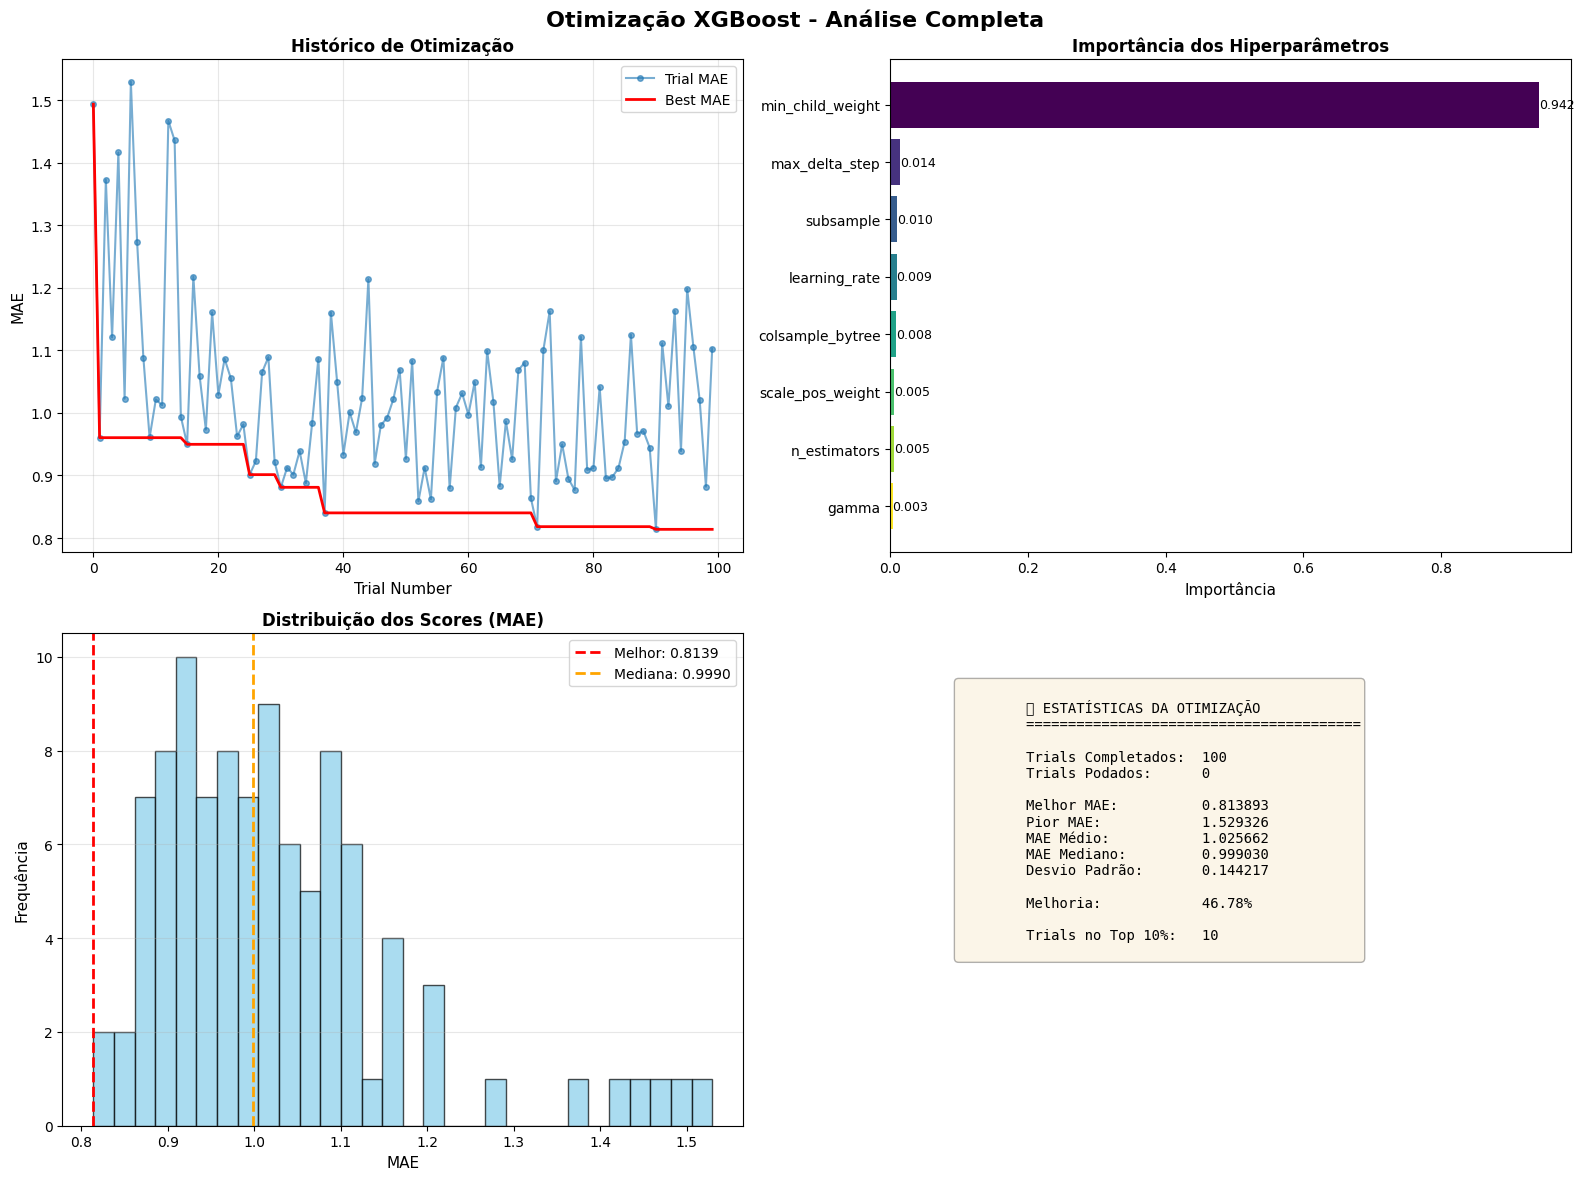

In [5]:
# ========================================================================
# TREINAR XGBOOST
# ========================================================================

print("\n" + "=" * 80)
print("🚀 TREINAMENTO XGBOOST")
print("=" * 80)

best_params_xgb, model_xgb, study_xgb = trainer.train_xgboost(
    n_trials=100,
    timeout=3600,
    plot_results=True
)


📊 AVALIAÇÃO NO CONJUNTO DE TESTE - XGBOOST

📈 MÉTRICAS - XGBOOST
--------------------------------------------------------------------------------
Métrica                   Train            Test             Gap
--------------------------------------------------------------------------------
MAE                      0.0665          0.6960         946.13%
RMSE                     0.1202          0.8649         619.86%
R²                       0.9921          0.0000               -
--------------------------------------------------------------------------------

🔍 EXECUTANDO DIAGNÓSTICO COMPLETO

🔍 DIAGNÓSTICO COMPLETO - XGBoost

📊 MÉTRICAS
MAE Train:  0.0665
MAE Test:   0.6960
Gap MAE:    +946.13%

RMSE Train: 0.1202
RMSE Test:  0.8649
Gap RMSE:   +619.86%

R² Train:   0.9921
R² Test:    0.0000

🚨 OVERFITTING SEVERO (gap > 50%) - Possível data leakage!

📊 ANÁLISE DE ERROS
Erro médio Train:   0.0665
Erro médio Test:    0.6960
Erro máximo Train:  0.6124
Erro máximo Test:   2.0490
% erros >

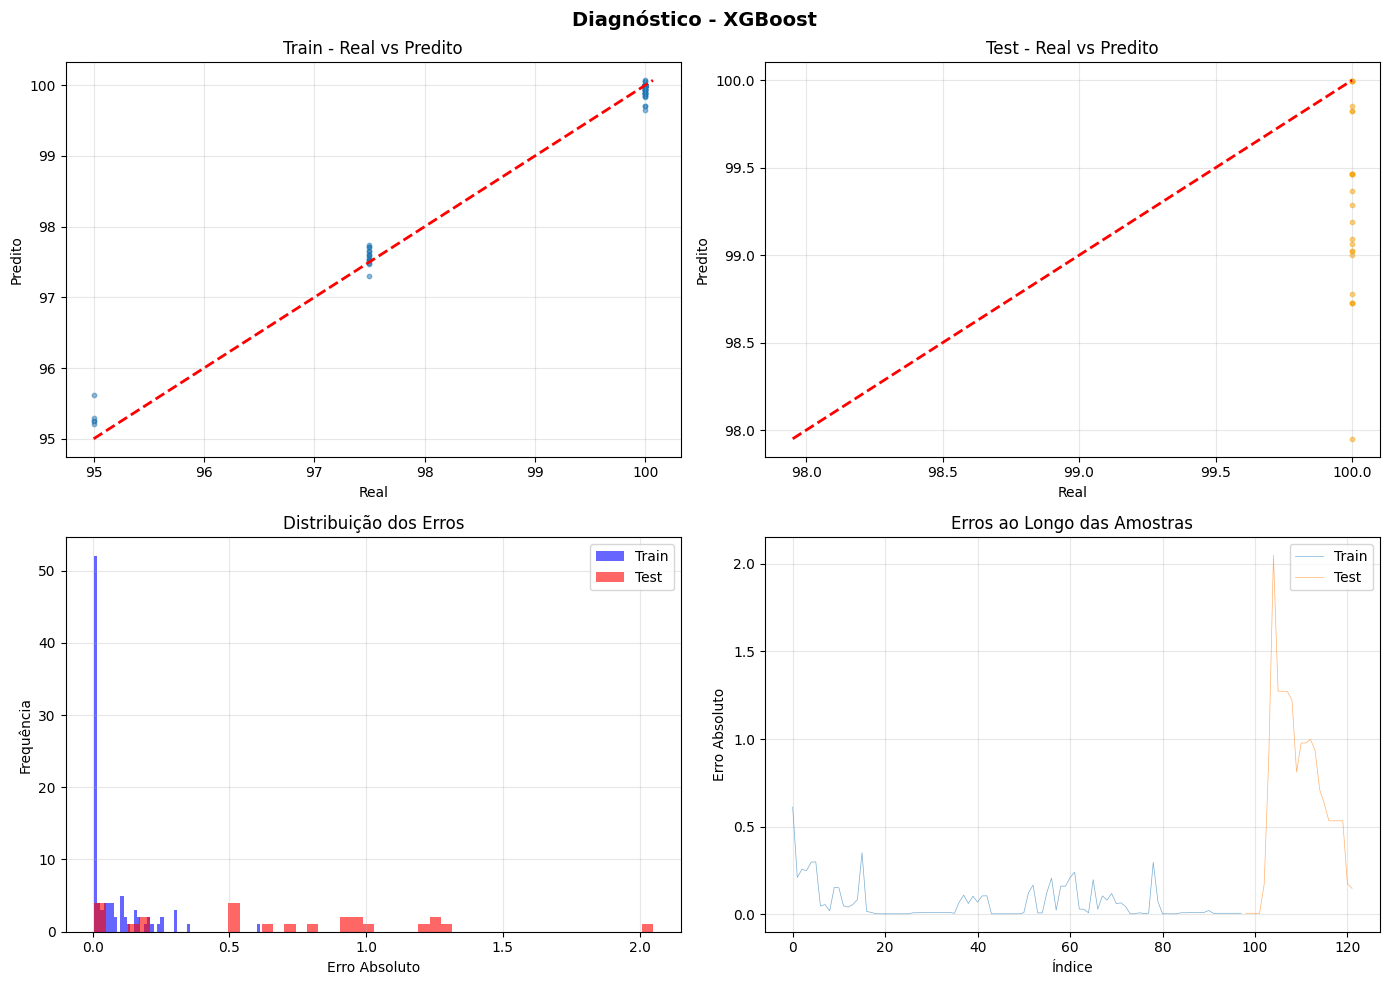

In [6]:
# ========================================================================
# AVALIAR NO CONJUNTO DE TESTE
# ========================================================================

print("\n" + "=" * 80)
print("📊 AVALIAÇÃO NO CONJUNTO DE TESTE - XGBOOST")
print("=" * 80)

# Fazer predições
y_pred_train_xgb = model_xgb.predict(X_train)
y_pred_test_xgb = model_xgb.predict(X_test)

# Calcular métricas
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test_xgb = mean_absolute_error(y_test, y_pred_test_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_test_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)
r2_test_xgb = r2_score(y_test, y_pred_test_xgb)

print(f"\n📈 MÉTRICAS - XGBOOST")
print("-" * 80)
print(f"{'Métrica':<15} {'Train':>15} {'Test':>15} {'Gap':>15}")
print("-" * 80)
print(f"{'MAE':<15} {mae_train_xgb:>15.4f} {mae_test_xgb:>15.4f} {((mae_test_xgb - mae_train_xgb)/mae_train_xgb * 100):>14.2f}%")
print(f"{'RMSE':<15} {rmse_train_xgb:>15.4f} {rmse_test_xgb:>15.4f} {((rmse_test_xgb - rmse_train_xgb)/rmse_train_xgb * 100):>14.2f}%")
print(f"{'R²':<15} {r2_train_xgb:>15.4f} {r2_test_xgb:>15.4f} {'-':>15}")
print("-" * 80)

# ========================================================================
# DIAGNÓSTICO COMPLETO
# ========================================================================

print("\n" + "=" * 80)
print("🔍 EXECUTANDO DIAGNÓSTICO COMPLETO")
print("=" * 80)

diagnostics_xgb = trainer.diagnose_model(
    model=model_xgb,
    X_test=X_test,
    y_test=y_test,
    model_name="XGBoost"
)

[I 2026-02-13 09:18:26,899] A new study created in memory with name: lightgbm_optimization



💡 TREINAMENTO LIGHTGBM
💡 TREINAMENTO LIGHTGBM COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: 3600 segundos



Best trial: 0. Best value: -1.06018:   1%|          | 1/100 [00:00<00:47,  2.07it/s, 0.48/3600 seconds]

[I 2026-02-13 09:18:27,386] Trial 0 finished with value: -1.060183991093305 and parameters: {'n_estimators': 700, 'learning_rate': 0.17254716573280354, 'num_leaves': 97, 'max_depth': 8, 'min_child_samples': 12, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'min_split_gain': 0.35403628889802274}. Best is trial 0 with value: -1.060183991093305.


Best trial: 1. Best value: -0.947416:   2%|▏         | 2/100 [00:00<00:42,  2.31it/s, 0.88/3600 seconds]

...

[I 2026-02-13 09:18:54,371] Trial 97 finished with value: -0.8925546517263225 and parameters: {'n_estimators': 400, 'learning_rate': 0.011128231461215665, 'num_leaves': 78, 'max_depth': 9, 'min_child_samples': 18, 'subsample': 0.6522506035004106, 'colsample_bytree': 0.6106977761945318, 'reg_alpha': 0.014466501486779798, 'reg_lambda': 0.001961157249333561, 'min_split_gain': 0.07142474264284053}. Best is trial 23 with value: -0.8188229429604532.


Best trial: 23. Best value: -0.818823:  99%|█████████▉| 99/100 [00:27<00:00,  3.47it/s, 27.88/3600 seconds]

[I 2026-02-13 09:18:54,782] Trial 98 finished with value: -0.853696368334272 and parameters: {'n_estimators': 800, 'learning_rate': 0.012533025807562234, 'num_leaves': 38, 'max_depth': 7, 'min_child_samples': 16, 'subsample': 0.9974411872746546, 'colsample_bytree': 0.7125543063302027, 'reg_alpha': 8.693579301829474e-06, 'reg_lambda': 1.2470835854053639e-06, 'min_split_gain': 0.042270568095604186}. Best is trial 23 with value: -0.8188229429604532.


Best trial: 23. Best value: -0.818823: 100%|██████████| 100/100 [00:28<00:00,  3.55it/s, 28.16/3600 seconds]


[I 2026-02-13 09:18:55,058] Trial 99 finished with value: -0.8832749183936485 and parameters: {'n_estimators': 600, 'learning_rate': 0.03057729819677728, 'num_leaves': 26, 'max_depth': 8, 'min_child_samples': 15, 'subsample': 0.6332724320704919, 'colsample_bytree': 0.6453030740036815, 'reg_alpha': 0.00011666468769819348, 'reg_lambda': 0.004988463866196449, 'min_split_gain': 0.10537240430761077}. Best is trial 23 with value: -0.8188229429604532.

✅ RESULTADOS - LIGHTGBM

⏱️ Tempo de treinamento: 0.47 minutos
🎯 Trials completados: 100
✂️ Trials podados: 0

📊 Melhor score (neg_mae): -0.8188
📊 MAE equivalente: 0.8188

🎯 MELHORES HIPERPARÂMETROS:
----------------------------------------------------------------------
  • colsample_bytree          0.7597
  • learning_rate             0.0119
  • max_depth                 4
  • min_child_samples         15
  • min_split_gain            0.1550
  • n_estimators              600
  • num_leaves                21
  • reg_alpha                 4.17e-

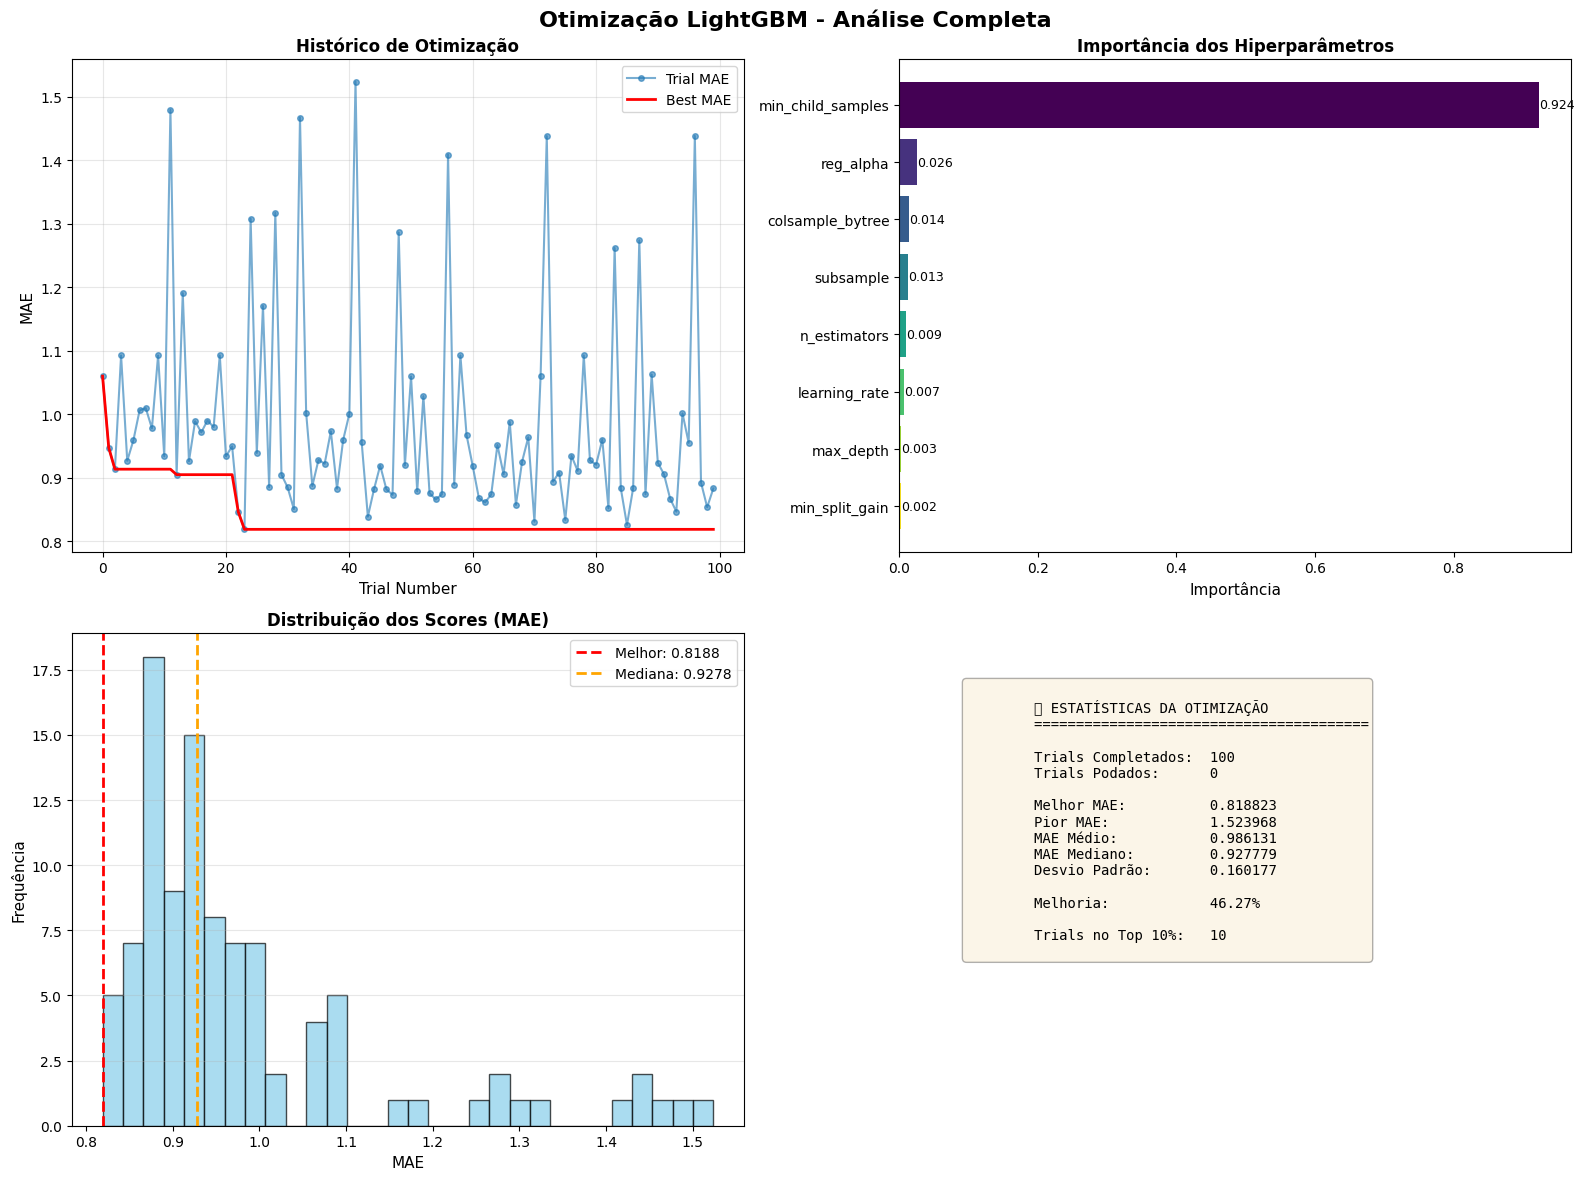

In [7]:
# ========================================================================
# TREINAR LIGHTGBM
# ========================================================================

print("\n" + "=" * 80)
print("💡 TREINAMENTO LIGHTGBM")
print("=" * 80)

best_params_lgb, model_lgb, study_lgb = trainer.train_lightgbm(
    n_trials=100,
    timeout=3600,
    plot_results=True
)


📈 MÉTRICAS - LIGHTGBM
--------------------------------------------------------------------------------
Métrica                   Train            Test             Gap
--------------------------------------------------------------------------------
MAE                      0.3300          0.7986         142.01%
RMSE                     0.5498          0.9557          73.84%
R²                       0.8344          0.0000               -
--------------------------------------------------------------------------------

🔍 DIAGNÓSTICO COMPLETO - LightGBM

📊 MÉTRICAS
MAE Train:  0.3300
MAE Test:   0.7986
Gap MAE:    +142.01%

RMSE Train: 0.5498
RMSE Test:  0.9557
Gap RMSE:   +73.84%

R² Train:   0.8344
R² Test:    0.0000

🚨 OVERFITTING SEVERO (gap > 50%) - Possível data leakage!

📊 ANÁLISE DE ERROS
Erro médio Train:   0.3300
Erro médio Test:    0.7986
Erro máximo Train:  1.9227
Erro máximo Test:   2.0650
% erros > 5 (Train): 0.0%
% erros > 5 (Test):  0.0%

📊 DISTRIBUIÇÃO DO TARGET
Train - M

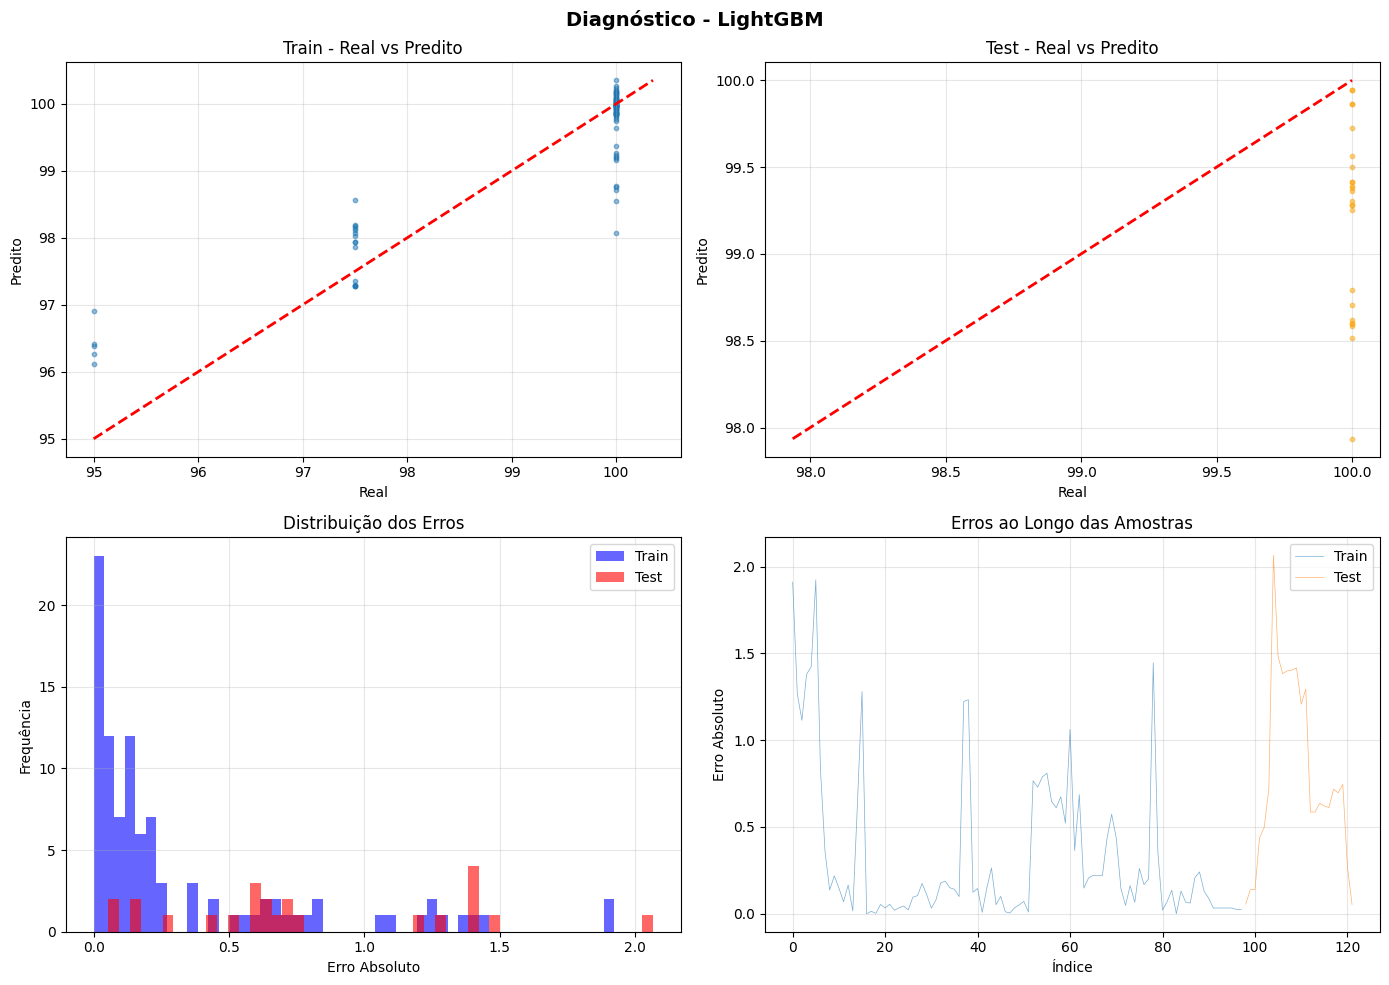

In [8]:
# Avaliar LightGBM
y_pred_train_lgb = model_lgb.predict(X_train)
y_pred_test_lgb = model_lgb.predict(X_test)

mae_train_lgb = mean_absolute_error(y_train, y_pred_train_lgb)
mae_test_lgb = mean_absolute_error(y_test, y_pred_test_lgb)
rmse_train_lgb = np.sqrt(mean_squared_error(y_train, y_pred_train_lgb))
rmse_test_lgb = np.sqrt(mean_squared_error(y_test, y_pred_test_lgb))
r2_train_lgb = r2_score(y_train, y_pred_train_lgb)
r2_test_lgb = r2_score(y_test, y_pred_test_lgb)

print(f"\n📈 MÉTRICAS - LIGHTGBM")
print("-" * 80)
print(f"{'Métrica':<15} {'Train':>15} {'Test':>15} {'Gap':>15}")
print("-" * 80)
print(f"{'MAE':<15} {mae_train_lgb:>15.4f} {mae_test_lgb:>15.4f} {((mae_test_lgb - mae_train_lgb)/mae_train_lgb * 100):>14.2f}%")
print(f"{'RMSE':<15} {rmse_train_lgb:>15.4f} {rmse_test_lgb:>15.4f} {((rmse_test_lgb - rmse_train_lgb)/rmse_train_lgb * 100):>14.2f}%")
print(f"{'R²':<15} {r2_train_lgb:>15.4f} {r2_test_lgb:>15.4f} {'-':>15}")
print("-" * 80)

# Diagnóstico LightGBM
diagnostics_lgb = trainer.diagnose_model(
    model=model_lgb,
    X_test=X_test,
    y_test=y_test,
    model_name="LightGBM"
)

[I 2026-02-13 09:18:57,974] A new study created in memory with name: randomforest_optimization



🌲 TREINAMENTO RANDOM FOREST
🌲 TREINAMENTO RANDOM FOREST COM OPTUNA
🎯 Número de trials: 80
⏱️ Timeout: 2400 segundos



Best trial: 0. Best value: -0.871403:   1%|▏         | 1/80 [00:00<01:02,  1.27it/s, 0.79/2400 seconds]

[I 2026-02-13 09:18:58,758] Trial 0 finished with value: -0.8714033123449607 and parameters: {'n_estimators': 450, 'max_depth': 6, 'max_features': 'log2', 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_samples': None, 'criterion': 'friedman_mse', 'min_impurity_decrease': 0.0013949386065204184, 'max_leaf_nodes': 200, 'ccp_alpha': 0.005142344384136116}. Best is trial 0 with value: -0.8714033123449607.


Best trial: 0. Best value: -0.871403:   2%|▎         | 2/80 [00:01<01:18,  1.00s/it, 1.94/2400 seconds]

...

[I 2026-02-13 09:23:08,388] Trial 77 finished with value: -0.88963418048374 and parameters: {'n_estimators': 950, 'max_depth': 10, 'max_features': 0.3, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_samples': 0.7, 'criterion': 'squared_error', 'min_impurity_decrease': 0.009565047854070823, 'max_leaf_nodes': 500, 'ccp_alpha': 0.008918189029748705}. Best is trial 57 with value: -0.49702400834162247.


Best trial: 57. Best value: -0.497024:  99%|█████████▉| 79/80 [04:11<00:01,  1.38s/it, 251.57/2400 seconds]

[I 2026-02-13 09:23:09,540] Trial 78 finished with value: -0.5073282523630419 and parameters: {'n_estimators': 700, 'max_depth': 6, 'max_features': 0.7, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_samples': None, 'criterion': 'absolute_error', 'min_impurity_decrease': 0.007632797136172994, 'max_leaf_nodes': 100, 'ccp_alpha': 0.009607872438655697}. Best is trial 57 with value: -0.49702400834162247.


Best trial: 79. Best value: -0.495992: 100%|██████████| 80/80 [04:12<00:00,  3.16s/it, 252.41/2400 seconds]


[I 2026-02-13 09:23:10,385] Trial 79 finished with value: -0.4959923269292877 and parameters: {'n_estimators': 600, 'max_depth': 10, 'max_features': 0.7, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_samples': 0.7, 'criterion': 'absolute_error', 'min_impurity_decrease': 0.006514569021530686, 'max_leaf_nodes': None, 'ccp_alpha': 0.001997854405104918}. Best is trial 79 with value: -0.4959923269292877.

✅ RESULTADOS - RANDOMFOREST

⏱️ Tempo de treinamento: 4.21 minutos
🎯 Trials completados: 80
✂️ Trials podados: 0

📊 Melhor score (neg_mae): -0.4960
📊 MAE equivalente: 0.4960

🎯 MELHORES HIPERPARÂMETROS:
----------------------------------------------------------------------
  • bootstrap                 True
  • ccp_alpha                 2.00e-03
  • criterion                 absolute_error
  • max_depth                 10
  • max_features              0.7000
  • max_leaf_nodes            None
  • max_samples               0.7000
  • min_impurity_decrease     6.51e-03
  • min_samples

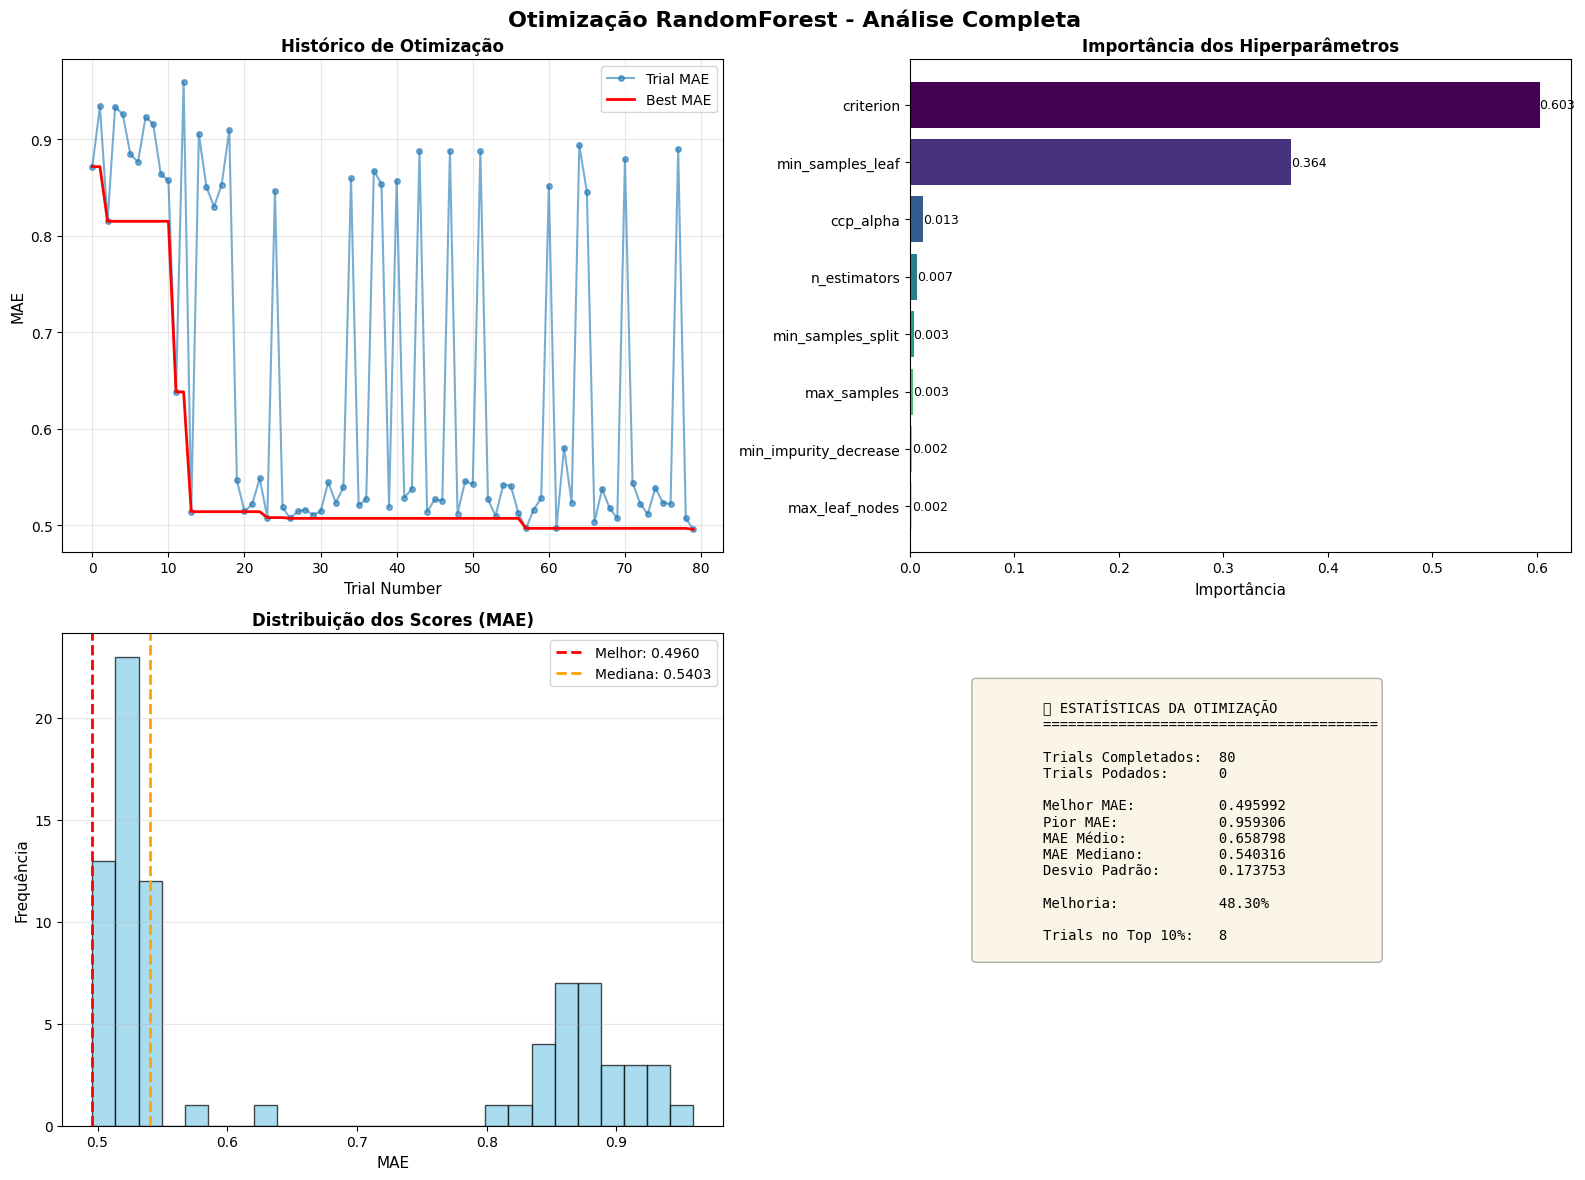

In [9]:
# ========================================================================
# TREINAR RANDOM FOREST
# ========================================================================

print("\n" + "=" * 80)
print("🌲 TREINAMENTO RANDOM FOREST")
print("=" * 80)

best_params_rf, model_rf, study_rf = trainer.train_randomforest(
    n_trials=80,
    timeout=2400,
    plot_results=True
)


📈 MÉTRICAS - RANDOM FOREST
--------------------------------------------------------------------------------
Métrica                   Train            Test             Gap
--------------------------------------------------------------------------------
MAE                      0.5450          0.3062         -43.81%
RMSE                     1.0474          0.3734         -64.35%
R²                       0.3990          0.0000               -
--------------------------------------------------------------------------------

🔍 DIAGNÓSTICO COMPLETO - RandomForest

📊 MÉTRICAS
MAE Train:  0.5450
MAE Test:   0.3062
Gap MAE:    -43.81%

RMSE Train: 1.0474
RMSE Test:  0.3734
Gap RMSE:   -64.35%

R² Train:   0.3990
R² Test:    0.0000

✅ Modelo bem generalizado (gap < 5%)

📊 ANÁLISE DE ERROS
Erro médio Train:   0.5450
Erro médio Test:    0.3062
Erro máximo Train:  4.6333
Erro máximo Test:   0.5208
% erros > 5 (Train): 0.0%
% erros > 5 (Test):  0.0%

📊 DISTRIBUIÇÃO DO TARGET
Train - Mean: 99.3622,

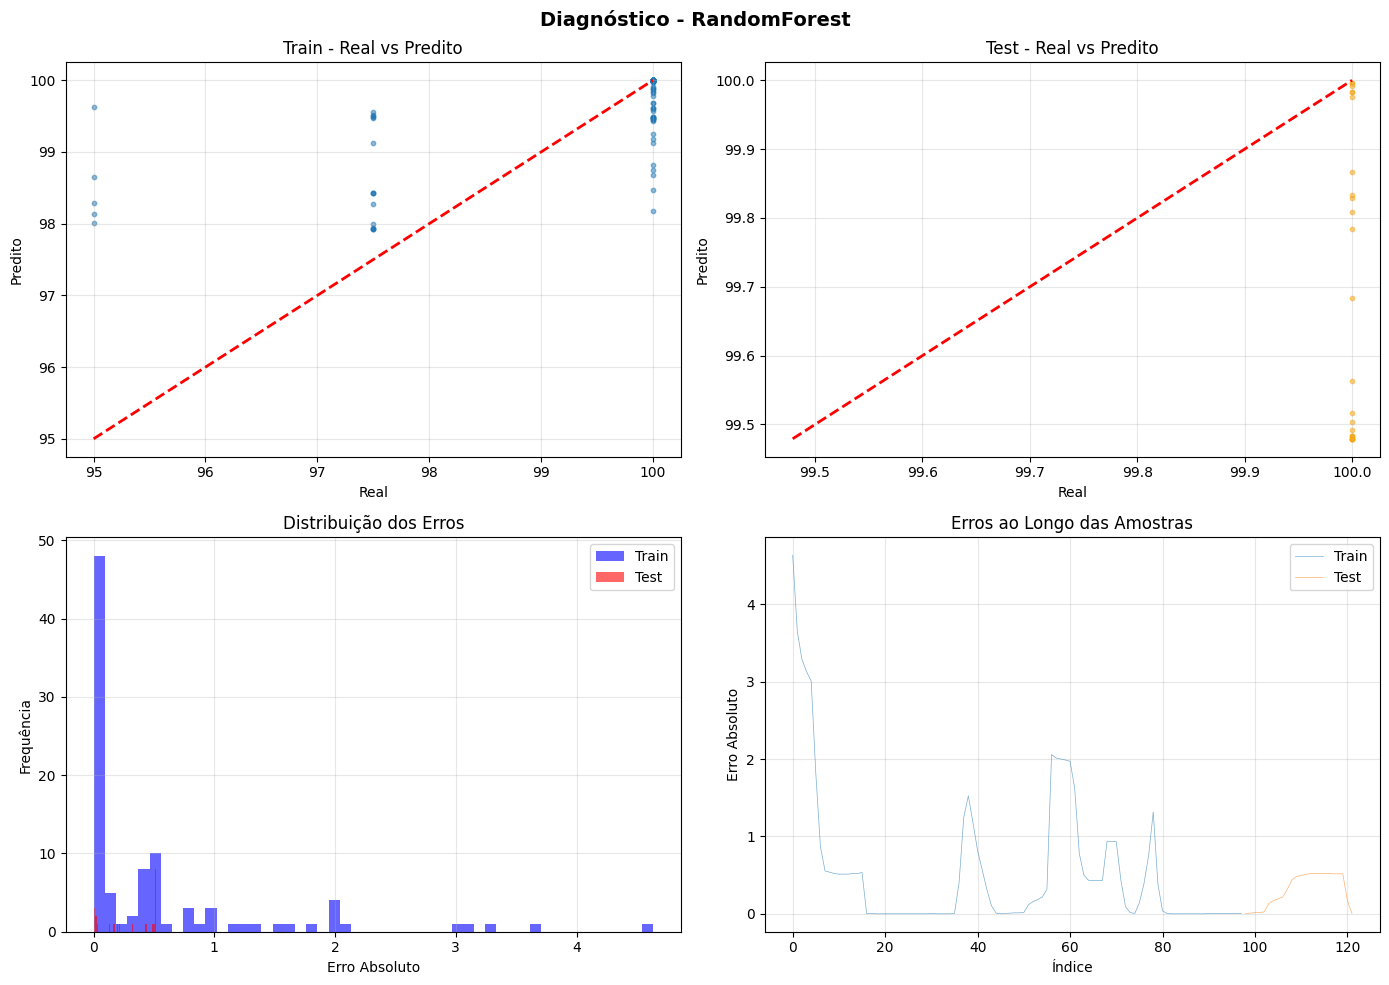

In [10]:
# Avaliar Random Forest
y_pred_train_rf = model_rf.predict(X_train)
y_pred_test_rf = model_rf.predict(X_test)

mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
mae_test_rf = mean_absolute_error(y_test, y_pred_test_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print(f"\n📈 MÉTRICAS - RANDOM FOREST")
print("-" * 80)
print(f"{'Métrica':<15} {'Train':>15} {'Test':>15} {'Gap':>15}")
print("-" * 80)
print(f"{'MAE':<15} {mae_train_rf:>15.4f} {mae_test_rf:>15.4f} {((mae_test_rf - mae_train_rf)/mae_train_rf * 100):>14.2f}%")
print(f"{'RMSE':<15} {rmse_train_rf:>15.4f} {rmse_test_rf:>15.4f} {((rmse_test_rf - rmse_train_rf)/rmse_train_rf * 100):>14.2f}%")
print(f"{'R²':<15} {r2_train_rf:>15.4f} {r2_test_rf:>15.4f} {'-':>15}")
print("-" * 80)

# Diagnóstico Random Forest
diagnostics_rf = trainer.diagnose_model(
    model=model_rf,
    X_test=X_test,
    y_test=y_test,
    model_name="RandomForest"
)

[I 2026-02-13 09:23:14,831] A new study created in memory with name: elasticnet_optimization



📏 TREINAMENTO ELASTICNET
📏 TREINAMENTO ELASTICNET COM OPTUNA
🎯 Número de trials: 60
⏱️ Timeout: 600 segundos
⚠️ ATENÇÃO: ElasticNet requer normalização dos dados



Best trial: 2. Best value: -0.831142:   3%|▎         | 2/60 [00:00<00:07,  7.63it/s, 0.14/600 seconds]

[I 2026-02-13 09:23:14,930] Trial 0 finished with value: -0.8525969410961367 and parameters: {'alpha': 0.029948298101271757, 'l1_ratio': 0.6488038815989345, 'tol': 0.0006920125881674312, 'selection': 'cyclic'}. Best is trial 0 with value: -0.8525969410961367.
[I 2026-02-13 09:23:14,935] Trial 1 finished with value: -0.857200545629402 and parameters: {'alpha': 0.022788916380083696, 'l1_ratio': 0.006648399073067135, 'tol': 8.022238951447359e-05, 'selection': 'cyclic'}. Best is trial 0 with value: -0.8525969410961367.
[I 2026-02-13 09:23:14,945] Trial 2 finished with value: -0.8311416402682225 and parameters: {'alpha': 0.058320987903324066, 'l1_ratio': 0.12248160874187797, 'tol': 7.924115738625992e-05, 'selection': 'random'}. Best is trial 2 with value: -0.8311416402682225.


Best trial: 2. Best value: -0.831142:   5%|▌         | 3/60 [00:00<00:07,  7.63it/s, 0.15/600 seconds]

...

[I 2026-02-13 09:23:15,431] Trial 36 finished with value: -0.8709312337043783 and parameters: {'alpha': 0.008914651556021716, 'l1_ratio': 0.5171595332851877, 'tol': 0.00010521535882590063, 'selection': 'cyclic'}. Best is trial 34 with value: -0.7688803251231277.
[I 2026-02-13 09:23:15,452] Trial 37 finished with value: -0.8740654702386031 and parameters: {'alpha': 0.005325178743878907, 'l1_ratio': 0.469543664388314, 'tol': 0.00012325844305430928, 'selection': 'cyclic'}. Best is trial 34 with value: -0.7688803251231277.
[I 2026-02-13 09:23:15,486] Trial 38 finished with value: -0.8266274386000307 and parameters: {'alpha': 0.06513621282664007, 'l1_ratio': 0.3572204148956952, 'tol': 0.0001098688152659652, 'selection': 'cyclic'}. Best is trial 34 with value: -0.7688803251231277.
[I 2026-02-13 09:23:15,512] Trial 39 finished with value: -0.8614258412016821 and parameters: {'alpha': 0.018073461929898445, 'l1_ratio': 0.1321569059947675, 'tol': 8.5863180862987e-05, 'selection': 'random'}. Best

Best trial: 43. Best value: -0.766609:  80%|████████  | 48/60 [00:00<00:00, 62.38it/s, 0.85/600 seconds]

[I 2026-02-13 09:23:15,545] Trial 42 finished with value: -0.7756339508727965 and parameters: {'alpha': 0.1994029224882814, 'l1_ratio': 0.21328329455698636, 'tol': 7.033774743598057e-05, 'selection': 'cyclic'}. Best is trial 34 with value: -0.7688803251231277.
[I 2026-02-13 09:23:15,567] Trial 43 finished with value: -0.7666094401830005 and parameters: {'alpha': 0.3743024032933795, 'l1_ratio': 0.19745589938626015, 'tol': 5.89108820134474e-05, 'selection': 'cyclic'}. Best is trial 43 with value: -0.7666094401830005.
[I 2026-02-13 09:23:15,579] Trial 44 finished with value: -0.7674812093495438 and parameters: {'alpha': 0.34696311382313294, 'l1_ratio': 0.23403961927657213, 'tol': 0.00018819770240186272, 'selection': 'cyclic'}. Best is trial 43 with value: -0.7666094401830005.
[I 2026-02-13 09:23:15,590] Trial 45 finished with value: -0.8632799004136584 and parameters: {'alpha': 1.3850965198441372, 'l1_ratio': 0.11111176340036019, 'tol': 9.521451486819695e-05, 'selection': 'cyclic'}. Best 

Best trial: 43. Best value: -0.766609: 100%|██████████| 60/60 [00:00<00:00, 64.94it/s, 0.92/600 seconds]


[I 2026-02-13 09:23:15,656] Trial 49 finished with value: -0.8690013129200218 and parameters: {'alpha': 0.01017575307438661, 'l1_ratio': 0.26635619551001344, 'tol': 4.926136352127076e-05, 'selection': 'cyclic'}. Best is trial 43 with value: -0.7666094401830005.
[I 2026-02-13 09:23:15,678] Trial 50 finished with value: -0.843740581818591 and parameters: {'alpha': 0.5535210690656508, 'l1_ratio': 0.48187239270757165, 'tol': 1.024034161233234e-05, 'selection': 'random'}. Best is trial 43 with value: -0.7666094401830005.
[I 2026-02-13 09:23:15,691] Trial 51 finished with value: -0.9751769679989933 and parameters: {'alpha': 3.9499175441804053, 'l1_ratio': 0.05202562395193752, 'tol': 0.00028913844339292744, 'selection': 'cyclic'}. Best is trial 43 with value: -0.7666094401830005.
[I 2026-02-13 09:23:15,707] Trial 52 finished with value: -0.8267854013815709 and parameters: {'alpha': 0.06544424212308154, 'l1_ratio': 0.18119363454130083, 'tol': 0.0001426582788897348, 'selection': 'cyclic'}. Best

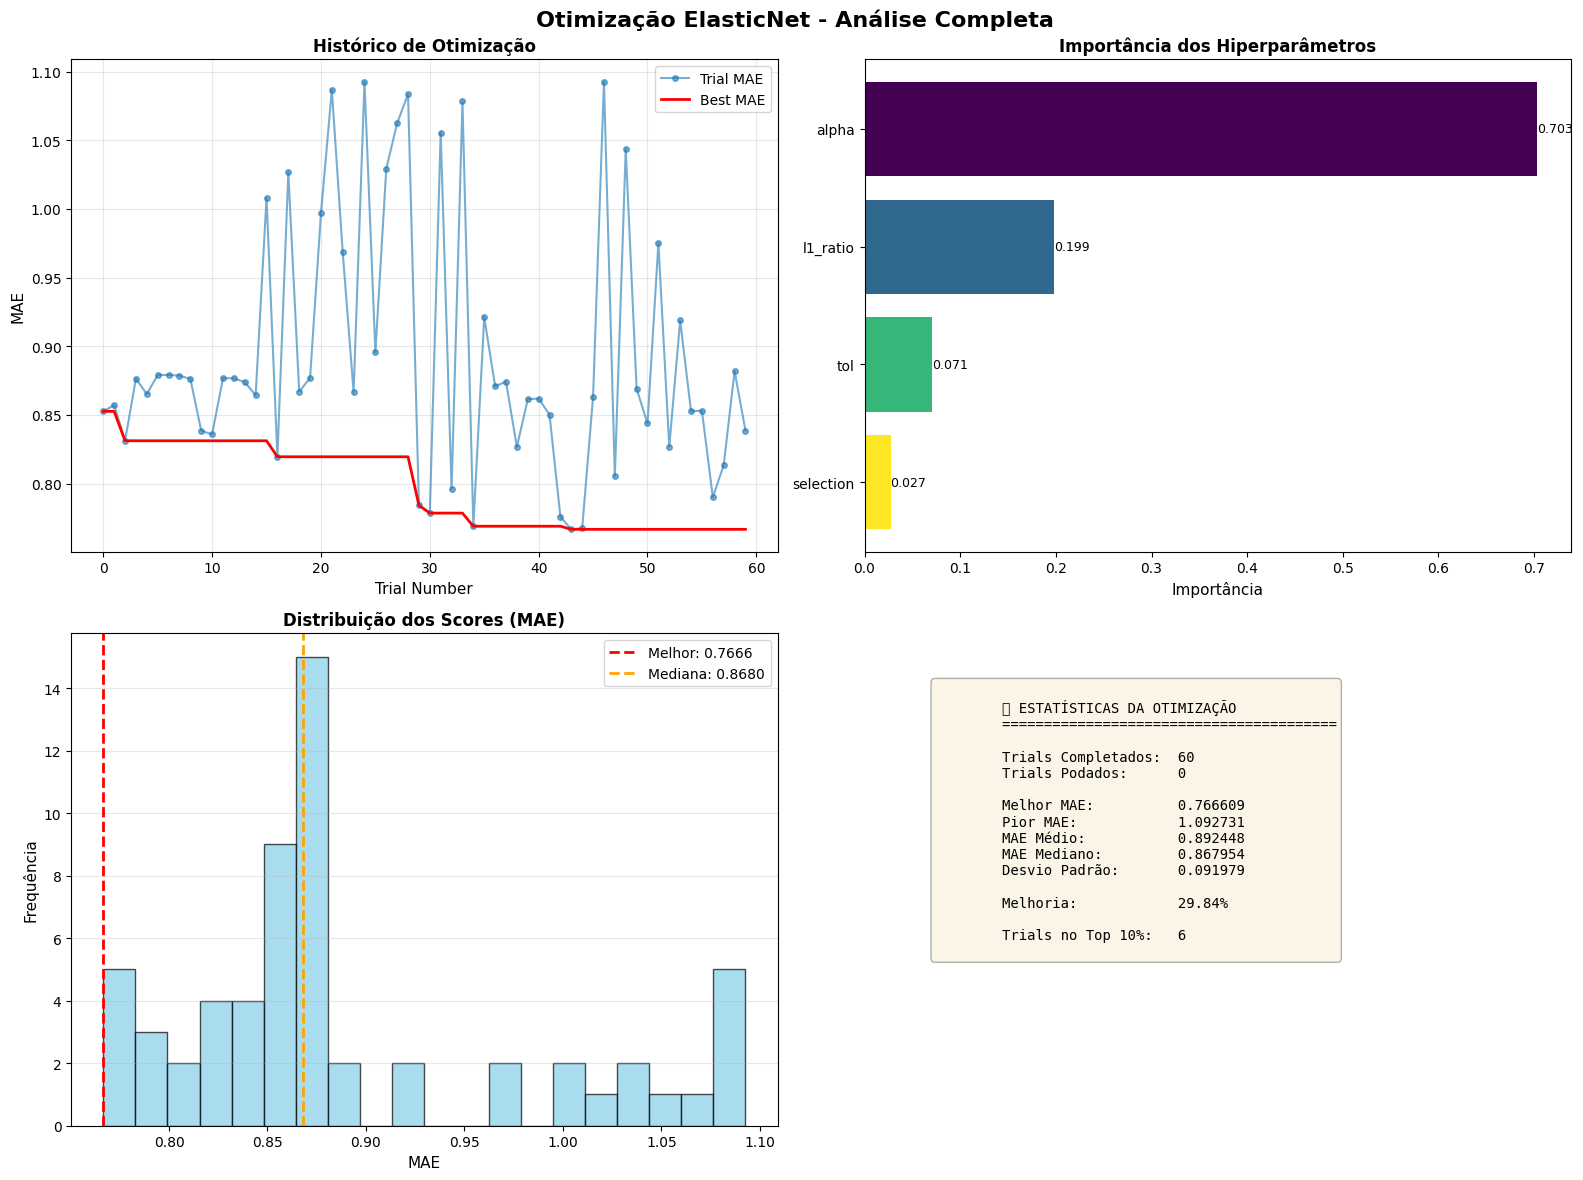

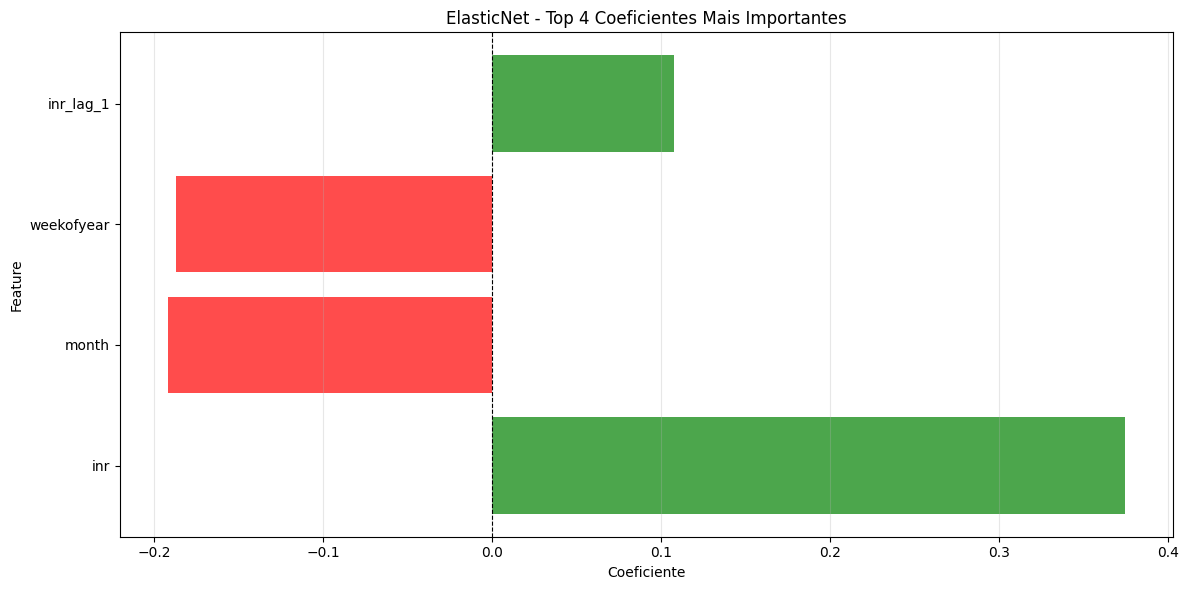

✅ Total de features com coef ≠ 0: 4/10


In [11]:
# ========================================================================
# TREINAR ELASTICNET
# ========================================================================

print("\n" + "=" * 80)
print("📏 TREINAMENTO ELASTICNET")
print("=" * 80)

best_params_elastic, model_elastic, study_elastic, scaler_elastic = trainer.train_elasticnet(
    n_trials=60,
    timeout=600,
    plot_results=True
)


📈 MÉTRICAS - ELASTICNET
--------------------------------------------------------------------------------
Métrica                   Train            Test             Gap
--------------------------------------------------------------------------------
MAE                      0.7478          0.9230          23.42%
RMSE                     1.0956          0.9863          -9.98%
R²                       0.3424          0.0000               -
--------------------------------------------------------------------------------

🔍 DIAGNÓSTICO COMPLETO - ElasticNet

📊 MÉTRICAS
MAE Train:  0.7478
MAE Test:   0.9230
Gap MAE:    +23.42%

RMSE Train: 1.0956
RMSE Test:  0.9863
Gap RMSE:   -9.98%

R² Train:   0.3424
R² Test:    0.0000

❌ Overfitting moderado (15% < gap < 50%)

📊 ANÁLISE DE ERROS
Erro médio Train:   0.7478
Erro médio Test:    0.9230
Erro máximo Train:  3.9085
Erro máximo Test:   1.2657
% erros > 5 (Train): 0.0%
% erros > 5 (Test):  0.0%

📊 DISTRIBUIÇÃO DO TARGET
Train - Mean: 99.3622, S

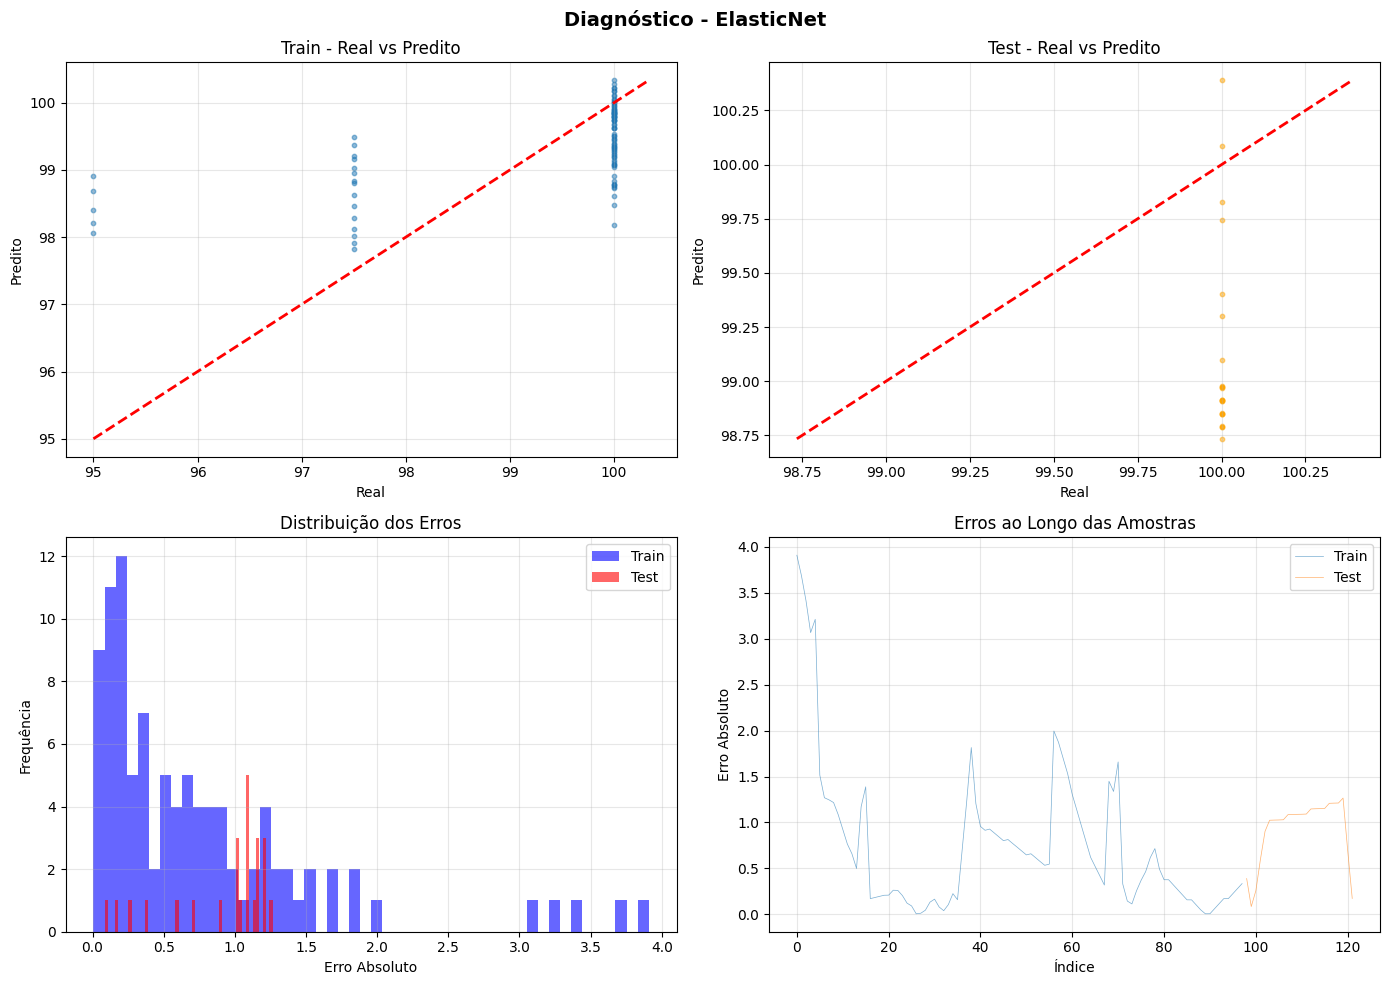

In [12]:
# IMPORTANTE: ElasticNet precisa do scaler!
X_train_scaled = scaler_elastic.transform(X_train)
X_test_scaled = scaler_elastic.transform(X_test)

y_pred_train_elastic = model_elastic.predict(X_train_scaled)
y_pred_test_elastic = model_elastic.predict(X_test_scaled)

mae_train_elastic = mean_absolute_error(y_train, y_pred_train_elastic)
mae_test_elastic = mean_absolute_error(y_test, y_pred_test_elastic)
rmse_train_elastic = np.sqrt(mean_squared_error(y_train, y_pred_train_elastic))
rmse_test_elastic = np.sqrt(mean_squared_error(y_test, y_pred_test_elastic))
r2_train_elastic = r2_score(y_train, y_pred_train_elastic)
r2_test_elastic = r2_score(y_test, y_pred_test_elastic)

print(f"\n📈 MÉTRICAS - ELASTICNET")
print("-" * 80)
print(f"{'Métrica':<15} {'Train':>15} {'Test':>15} {'Gap':>15}")
print("-" * 80)
print(f"{'MAE':<15} {mae_train_elastic:>15.4f} {mae_test_elastic:>15.4f} {((mae_test_elastic - mae_train_elastic)/mae_train_elastic * 100):>14.2f}%")
print(f"{'RMSE':<15} {rmse_train_elastic:>15.4f} {rmse_test_elastic:>15.4f} {((rmse_test_elastic - rmse_train_elastic)/rmse_train_elastic * 100):>14.2f}%")
print(f"{'R²':<15} {r2_train_elastic:>15.4f} {r2_test_elastic:>15.4f} {'-':>15}")
print("-" * 80)

# Diagnóstico ElasticNet
diagnostics_elastic = trainer.diagnose_model(
    model=model_elastic,
    X_test=X_test,
    y_test=y_test,
    model_name="ElasticNet",
    scaler=scaler_elastic
)

In [13]:
# ========================================================================
# COMPARAÇÃO FINAL DE TODOS OS MODELOS
# ========================================================================

print("\n" + "=" * 80)
print("🏆 COMPARAÇÃO FINAL - TODOS OS MODELOS")
print("=" * 80)

# Criar DataFrame comparativo
comparison_data = {
    'Modelo': ['XGBoost', 'LightGBM', 'RandomForest', 'ElasticNet'],
    'MAE_Train': [mae_train_xgb, mae_train_lgb, mae_train_rf, mae_train_elastic],
    'MAE_Test': [mae_test_xgb, mae_test_lgb, mae_test_rf, mae_test_elastic],
    'RMSE_Train': [rmse_train_xgb, rmse_train_lgb, rmse_train_rf, rmse_train_elastic],
    'RMSE_Test': [rmse_test_xgb, rmse_test_lgb, rmse_test_rf, rmse_test_elastic],
    'R2_Train': [r2_train_xgb, r2_train_lgb, r2_train_rf, r2_train_elastic],
    'R2_Test': [r2_test_xgb, r2_test_lgb, r2_test_rf, r2_test_elastic]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison['MAE_Gap_%'] = ((df_comparison['MAE_Test'] - df_comparison['MAE_Train']) / 
                               df_comparison['MAE_Train'] * 100)
df_comparison['RMSE_Gap_%'] = ((df_comparison['RMSE_Test'] - df_comparison['RMSE_Train']) / 
                                df_comparison['RMSE_Train'] * 100)

# Ordenar por MAE_Test
df_comparison = df_comparison.sort_values('MAE_Test')

print("\n📊 TABELA COMPARATIVA")
print(df_comparison.to_string(index=False))

# Identificar melhor modelo
best_model_name = df_comparison.iloc[0]['Modelo']
best_mae = df_comparison.iloc[0]['MAE_Test']

print("\n" + "=" * 80)
print(f"🥇 MELHOR MODELO: {best_model_name}")
print(f"📊 MAE no Test: {best_mae:.4f}")
print("=" * 80)


🏆 COMPARAÇÃO FINAL - TODOS OS MODELOS

📊 TABELA COMPARATIVA
      Modelo  MAE_Train  MAE_Test  RMSE_Train  RMSE_Test  R2_Train  R2_Test  MAE_Gap_%  RMSE_Gap_%
RandomForest   0.545026  0.306250    1.047438   0.373409  0.398970      0.0 -43.809970  -64.350254
     XGBoost   0.066527  0.695961    0.120156   0.864949  0.992091      0.0 946.128300  619.855049
    LightGBM   0.329989  0.798596    0.549781   0.955735  0.834416      0.0 142.006722   73.839291
  ElasticNet   0.747848  0.923026    1.095616   0.986315  0.342408      0.0  23.424376   -9.976275

🥇 MELHOR MODELO: RandomForest
📊 MAE no Test: 0.3062



📈 GERANDO VISUALIZAÇÕES COMPARATIVAS


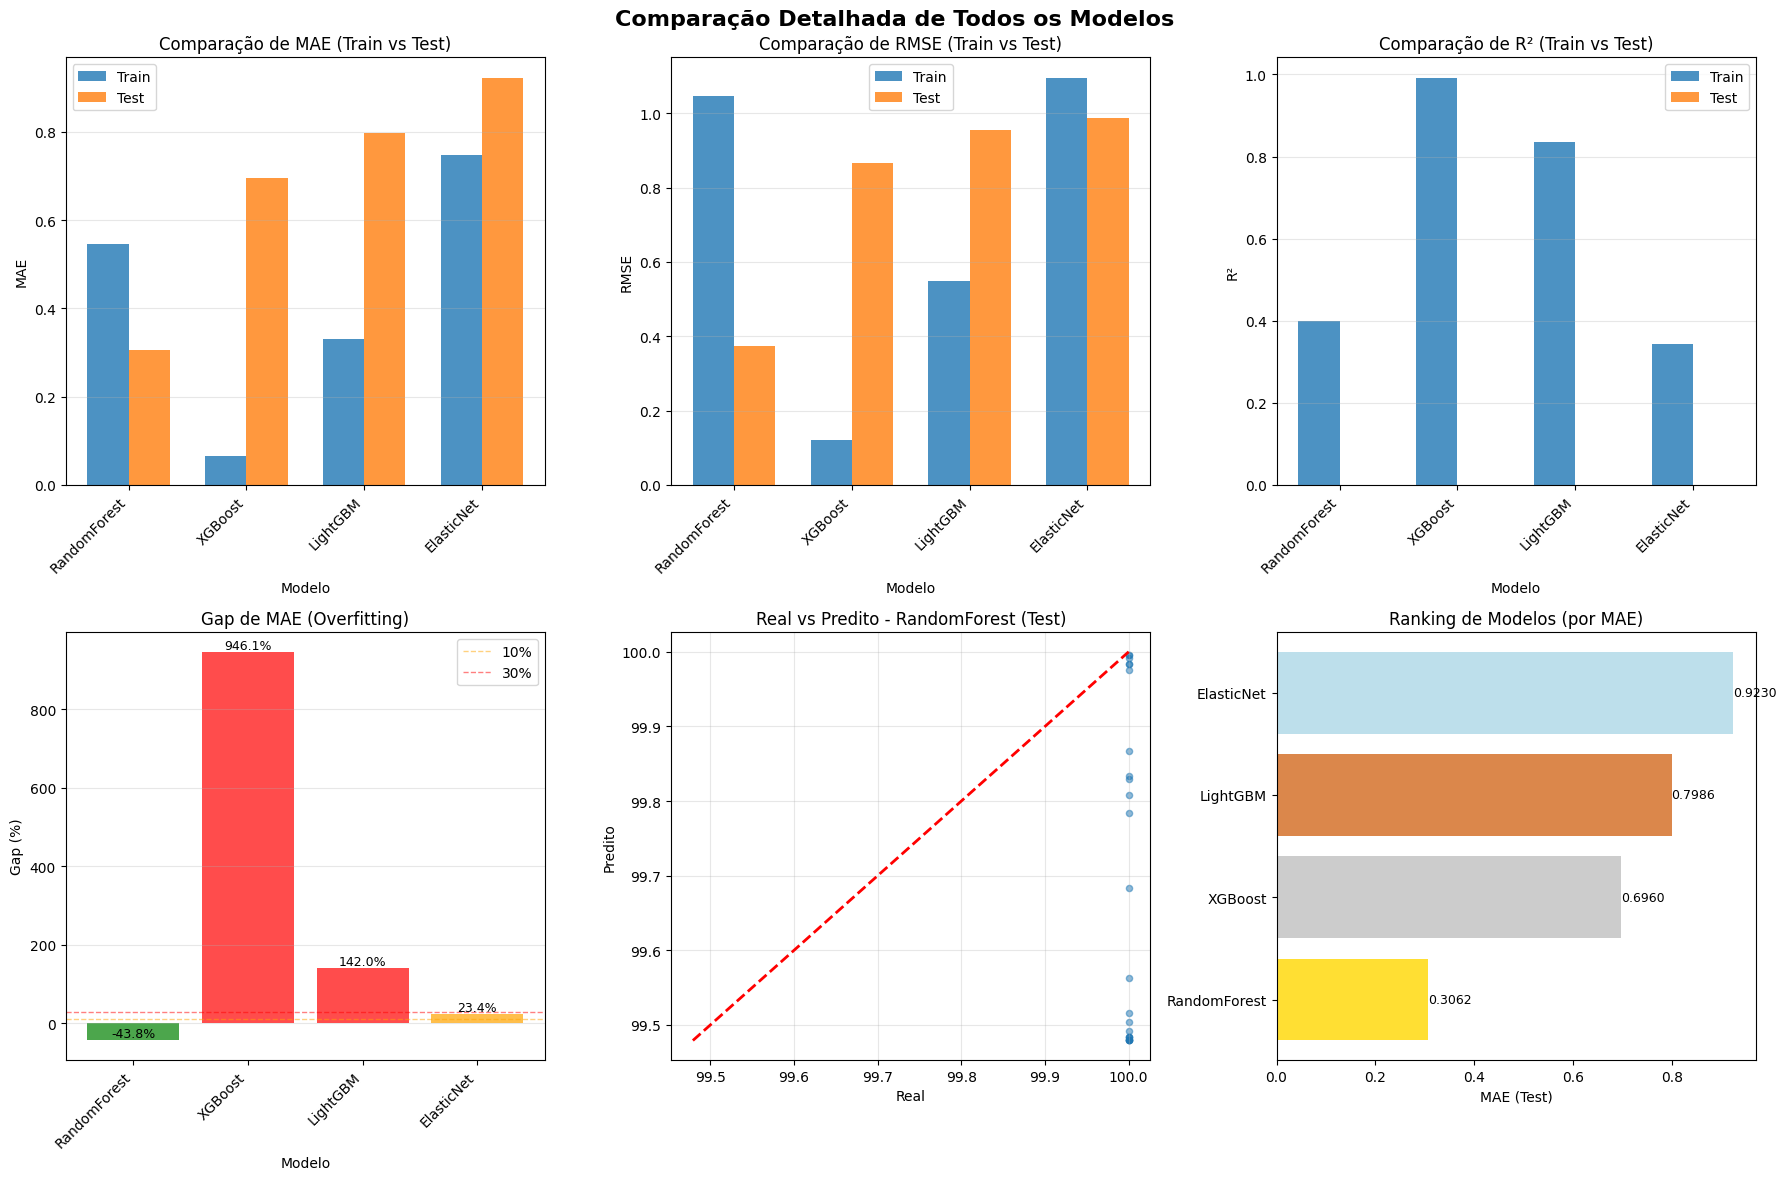

In [14]:
# ========================================================================
# VISUALIZAÇÕES COMPARATIVAS
# ========================================================================

print("\n" + "=" * 80)
print("📈 GERANDO VISUALIZAÇÕES COMPARATIVAS")
print("=" * 80)

# Criar figura com múltiplos subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comparação Detalhada de Todos os Modelos', fontsize=16, fontweight='bold')

# 1. Comparação de MAE
ax1 = axes[0, 0]
x_pos = np.arange(len(df_comparison))
width = 0.35
ax1.bar(x_pos - width/2, df_comparison['MAE_Train'], width, label='Train', alpha=0.8)
ax1.bar(x_pos + width/2, df_comparison['MAE_Test'], width, label='Test', alpha=0.8)
ax1.set_xlabel('Modelo')
ax1.set_ylabel('MAE')
ax1.set_title('Comparação de MAE (Train vs Test)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Comparação de RMSE
ax2 = axes[0, 1]
ax2.bar(x_pos - width/2, df_comparison['RMSE_Train'], width, label='Train', alpha=0.8)
ax2.bar(x_pos + width/2, df_comparison['RMSE_Test'], width, label='Test', alpha=0.8)
ax2.set_xlabel('Modelo')
ax2.set_ylabel('RMSE')
ax2.set_title('Comparação de RMSE (Train vs Test)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Comparação de R²
ax3 = axes[0, 2]
ax3.bar(x_pos - width/2, df_comparison['R2_Train'], width, label='Train', alpha=0.8)
ax3.bar(x_pos + width/2, df_comparison['R2_Test'], width, label='Test', alpha=0.8)
ax3.set_xlabel('Modelo')
ax3.set_ylabel('R²')
ax3.set_title('Comparação de R² (Train vs Test)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Gap de MAE
ax4 = axes[1, 0]
colors = ['green' if gap < 10 else 'orange' if gap < 30 else 'red' 
          for gap in df_comparison['MAE_Gap_%']]
bars = ax4.bar(df_comparison['Modelo'], df_comparison['MAE_Gap_%'], color=colors, alpha=0.7)
ax4.set_xlabel('Modelo')
ax4.set_ylabel('Gap (%)')
ax4.set_title('Gap de MAE (Overfitting)')
ax4.axhline(y=10, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='10%')
ax4.axhline(y=30, color='red', linestyle='--', linewidth=1, alpha=0.5, label='30%')
ax4.set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bar, gap in zip(bars, df_comparison['MAE_Gap_%']):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{gap:.1f}%', ha='center', va='bottom', fontsize=9)

# 5. Real vs Predito - Melhor Modelo
ax5 = axes[1, 1]
if best_model_name == 'XGBoost':
    y_pred_best = y_pred_test_xgb
elif best_model_name == 'LightGBM':
    y_pred_best = y_pred_test_lgb
elif best_model_name == 'RandomForest':
    y_pred_best = y_pred_test_rf
else:
    y_pred_best = y_pred_test_elastic

ax5.scatter(y_test, y_pred_best, alpha=0.5, s=20)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax5.set_xlabel('Real')
ax5.set_ylabel('Predito')
ax5.set_title(f'Real vs Predito - {best_model_name} (Test)')
ax5.grid(True, alpha=0.3)

# 6. Ranking de Modelos
ax6 = axes[1, 2]
df_sorted = df_comparison.sort_values('MAE_Test', ascending=False)
colors_rank = ['gold' if i == len(df_sorted)-1 else 'silver' if i == len(df_sorted)-2 
               else 'chocolate' if i == len(df_sorted)-3 else 'lightblue' 
               for i in range(len(df_sorted))]
bars = ax6.barh(df_sorted['Modelo'], df_sorted['MAE_Test'], color=colors_rank, alpha=0.8)
ax6.set_xlabel('MAE (Test)')
ax6.set_title('Ranking de Modelos (por MAE)')
ax6.invert_yaxis()

# Adicionar valores
for bar, mae in zip(bars, df_sorted['MAE_Test']):
    width = bar.get_width()
    ax6.text(width, bar.get_y() + bar.get_height()/2.,
            f'{mae:.4f}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


📊 ANÁLISE DE RESÍDUOS - RandomForest


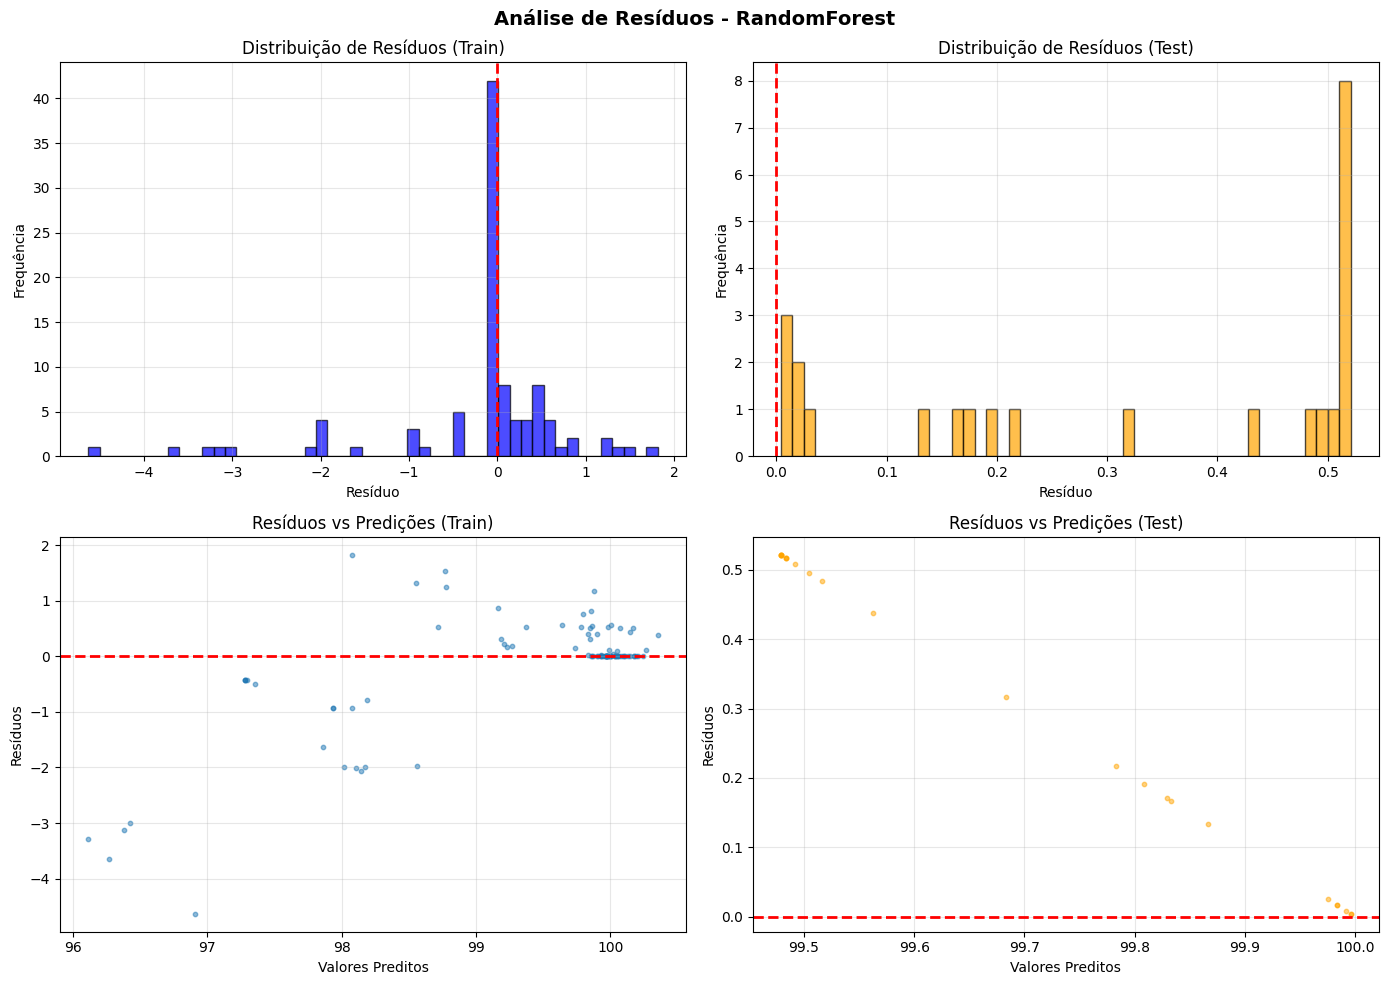

In [15]:
# ========================================================================
# ANÁLISE DE RESÍDUOS - MELHOR MODELO
# ========================================================================

print("\n" + "=" * 80)
print(f"📊 ANÁLISE DE RESÍDUOS - {best_model_name}")
print("=" * 80)

# Calcular resíduos
residuals_train = y_train - (y_pred_train_xgb if best_model_name == 'XGBoost' 
                              else y_pred_train_lgb if best_model_name == 'LightGBM'
                              else y_pred_train_rf if best_model_name == 'RandomForest'
                              else y_pred_train_elastic)

residuals_test = y_test - y_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Análise de Resíduos - {best_model_name}', fontsize=14, fontweight='bold')

# 1. Distribuição de resíduos (Train)
axes[0, 0].hist(residuals_train, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Resíduo')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição de Resíduos (Train)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribuição de resíduos (Test)
axes[0, 1].hist(residuals_test, bins=50, alpha=0.7, color='orange', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Resíduo')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição de Resíduos (Test)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Resíduos vs Predições (Train)
axes[1, 0].scatter(y_pred_train_xgb if best_model_name == 'XGBoost' else y_pred_train_lgb,
                   residuals_train, alpha=0.5, s=10)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Valores Preditos')
axes[1, 0].set_ylabel('Resíduos')
axes[1, 0].set_title('Resíduos vs Predições (Train)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Resíduos vs Predições (Test)
axes[1, 1].scatter(y_pred_best, residuals_test, alpha=0.5, s=10, color='orange')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Valores Preditos')
axes[1, 1].set_ylabel('Resíduos')
axes[1, 1].set_title('Resíduos vs Predições (Test)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ========================================================================
# RESUMO FINAL
# ========================================================================

print("\n" + "=" * 80)
print("🎯 RESUMO FINAL DA ANÁLISE")
print("=" * 80)

print(f"\n🏆 MELHOR MODELO: {best_model_name}")
print(f"📊 MAE no Test: {best_mae:.4f}")
print(f"📊 RMSE no Test: {df_comparison[df_comparison['Modelo'] == best_model_name]['RMSE_Test'].values[0]:.4f}")
print(f"📊 R² no Test: {df_comparison[df_comparison['Modelo'] == best_model_name]['R2_Test'].values[0]:.4f}")
print(f"📊 Gap MAE: {df_comparison[df_comparison['Modelo'] == best_model_name]['MAE_Gap_%'].values[0]:.2f}%")

print("\n📋 ANÁLISE DE OVERFITTING:")
for idx, row in df_comparison.iterrows():
    gap = row['MAE_Gap_%']
    status = "✅ Ótimo" if gap < 10 else "⚠️ Moderado" if gap < 30 else "❌ Alto"
    print(f"  {row['Modelo']:<15} Gap: {gap:>6.2f}% {status}")

print("\n🔍 ANÁLISE DE DATA LEAKAGE:")
for model_name in ['XGBoost', 'LightGBM', 'RandomForest', 'ElasticNet']:
    diag_key = model_name
    if diag_key in trainer.diagnostics_history:
        n_suspicious = len(trainer.diagnostics_history[diag_key]['suspicious_features'])
        status = "✅ OK" if n_suspicious == 0 else f"⚠️ {n_suspicious} features suspeitas"
        print(f"  {model_name:<15} {status}")

print("\n" + "=" * 80)
print("✅ ANÁLISE COMPLETA FINALIZADA")
print("=" * 80)


🎯 RESUMO FINAL DA ANÁLISE

🏆 MELHOR MODELO: RandomForest
📊 MAE no Test: 0.3062
📊 RMSE no Test: 0.3734
📊 R² no Test: 0.0000
📊 Gap MAE: -43.81%

📋 ANÁLISE DE OVERFITTING:
  RandomForest    Gap: -43.81% ✅ Ótimo
  XGBoost         Gap: 946.13% ❌ Alto
  LightGBM        Gap: 142.01% ❌ Alto
  ElasticNet      Gap:  23.42% ⚠️ Moderado

🔍 ANÁLISE DE DATA LEAKAGE:
  XGBoost         ✅ OK
  LightGBM        ✅ OK
  RandomForest    ✅ OK
  ElasticNet      ✅ OK

✅ ANÁLISE COMPLETA FINALIZADA


In [ ]:
# ========================================================================
# SALVAR RESULTADOS
# ========================================================================

print("\n" + "=" * 80)
print("💾 SALVANDO RESULTADOS")
print("=" * 80)

# Salvar comparação em CSV
df_comparison.to_csv('model_comparison_results.csv', index=False)
print("✅ Comparação salva em: model_comparison_results.csv")

# Salvar diagnósticos
diagnostics_summary = pd.DataFrame({
    'Modelo': ['XGBoost', 'LightGBM', 'RandomForest', 'ElasticNet'],
    'MAE_Test': [diagnostics_xgb['mae_test'], diagnostics_lgb['mae_test'], 
                 diagnostics_rf['mae_test'], diagnostics_elastic['mae_test']],
    'Gap_MAE_%': [diagnostics_xgb['mae_gap_percent'], diagnostics_lgb['mae_gap_percent'],
                  diagnostics_rf['mae_gap_percent'], diagnostics_elastic['mae_gap_percent']],
    'Features_Suspeitas': [len(diagnostics_xgb['suspicious_features']), 
                          len(diagnostics_lgb['suspicious_features']),
                          len(diagnostics_rf['suspicious_features']),
                          len(diagnostics_elastic['suspicious_features'])],
    'KS_Test_PValue': [diagnostics_xgb['ks_test_pvalue'], diagnostics_lgb['ks_test_pvalue'],
                       diagnostics_rf['ks_test_pvalue'], diagnostics_elastic['ks_test_pvalue']]
})

diagnostics_summary.to_csv('model_diagnostics_summary.csv', index=False)
print("✅ Diagnósticos salvos em: model_diagnostics_summary.csv")

# Salvar histórico do trainer
history_df = trainer.get_training_history()
history_df.to_csv('training_history.csv', index=False)
print("✅ Histórico de treinamento salvo em: training_history.csv")

#### Versão 1

[I 2026-02-13 04:16:33,524] A new study created in memory with name: xgboost_optimization


✅ ModelTrainer Inicializado
📊 Shape X_train: (98, 10)
📊 Shape y_train: (98,)
🔢 Número de features: 10
🔄 Cross-validation folds: 5
🎲 Random state: 42


🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE

🚀 INICIANDO TREINAMENTO DE TODOS OS MODELOS
Modelos a treinar: ['xgboost', 'lightgbm', 'randomforest', 'elasticnet']
Total de trials: 340

🚀 TREINAMENTO XGBOOST COM OPTUNA
🎯 Número de trials: 100
⏱️ Timeout: Sem limite segundos



Best trial: 0. Best value: -1.49335:   1%|          | 1/100 [00:03<05:16,  3.19s/it]

[I 2026-02-13 04:16:36,715] Trial 0 finished with value: -1.4933453834258152 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -1.4933453834258152.


Best trial: 1. Best value: -0.960402:   2%|▏         | 2/100 [00:05<04:08,  2.53s/it]

...

[I 2026-02-13 04:18:43,114] Trial 30 finished with value: -0.819923359094625 and parameters: {'alpha': 0.076320645883852, 'l1_ratio': 0.9645204660859239, 'tol': 0.00011364378723759072, 'selection': 'cyclic'}. Best is trial 28 with value: -0.7798475919809826.
[I 2026-02-13 04:18:43,120] Trial 31 finished with value: -0.8165754675308963 and parameters: {'alpha': 0.08410664974843714, 'l1_ratio': 0.8025538583472137, 'tol': 2.3810280138876808e-05, 'selection': 'cyclic'}. Best is trial 28 with value: -0.7798475919809826.
[I 2026-02-13 04:18:43,142] Trial 32 finished with value: -0.8181290492506791 and parameters: {'alpha': 0.2670077136671085, 'l1_ratio': 0.8965387396116778, 'tol': 1.0344389233662253e-05, 'selection': 'cyclic'}. Best is trial 28 with value: -0.7798475919809826.
[I 2026-02-13 04:18:43,152] Trial 33 finished with value: -0.7737783205335971 and parameters: {'alpha': 0.18752334294777742, 'l1_ratio': 0.616262600918237, 'tol': 0.0008390942437534557, 'selection': 'random'}. Best is 

Best trial: 46. Best value: -0.770228:  78%|███████▊  | 47/60 [00:00<00:00, 86.82it/s]

[I 2026-02-13 04:18:43,296] Trial 45 finished with value: -0.7835528777801348 and parameters: {'alpha': 0.14628722826064078, 'l1_ratio': 0.6324159603003975, 'tol': 0.0007832760068952547, 'selection': 'random'}. Best is trial 33 with value: -0.7737783205335971.
[I 2026-02-13 04:18:43,296] Trial 44 finished with value: -1.0053510583559284 and parameters: {'alpha': 0.6469290124125605, 'l1_ratio': 0.8680727789600089, 'tol': 0.0004895727339773306, 'selection': 'random'}. Best is trial 33 with value: -0.7737783205335971.
[I 2026-02-13 04:18:43,301] Trial 46 finished with value: -0.7702283799989367 and parameters: {'alpha': 0.2283172990871788, 'l1_ratio': 0.5714113134191736, 'tol': 0.0004433846297552395, 'selection': 'random'}. Best is trial 46 with value: -0.7702283799989367.
[I 2026-02-13 04:18:43,307] Trial 47 finished with value: -0.9949418967452073 and parameters: {'alpha': 1.3213213387247378, 'l1_ratio': 0.353295486701101, 'tol': 0.000633747954766305, 'selection': 'random'}. Best is tri

Best trial: 48. Best value: -0.769764: 100%|██████████| 60/60 [00:00<00:00, 94.09it/s]


[I 2026-02-13 04:18:43,324] Trial 48 finished with value: -0.7697641851063306 and parameters: {'alpha': 0.21004085058414657, 'l1_ratio': 0.5381053104587006, 'tol': 0.0007441507319570961, 'selection': 'random'}. Best is trial 48 with value: -0.7697641851063306.
[I 2026-02-13 04:18:43,339] Trial 49 finished with value: -0.8367467309567193 and parameters: {'alpha': 0.5259183216118105, 'l1_ratio': 0.49352315998715746, 'tol': 0.0006000199835164155, 'selection': 'random'}. Best is trial 48 with value: -0.7697641851063306.
[I 2026-02-13 04:18:43,353] Trial 50 finished with value: -0.9034784058780413 and parameters: {'alpha': 0.5578128324085214, 'l1_ratio': 0.6904402819668913, 'tol': 0.0005463939584300179, 'selection': 'random'}. Best is trial 48 with value: -0.7697641851063306.
[I 2026-02-13 04:18:43,361] Trial 55 finished with value: -0.8636628596830289 and parameters: {'alpha': 0.017714498622565553, 'l1_ratio': 0.72127372531305, 'tol': 0.0007034432730611464, 'selection': 'random'}. Best is 

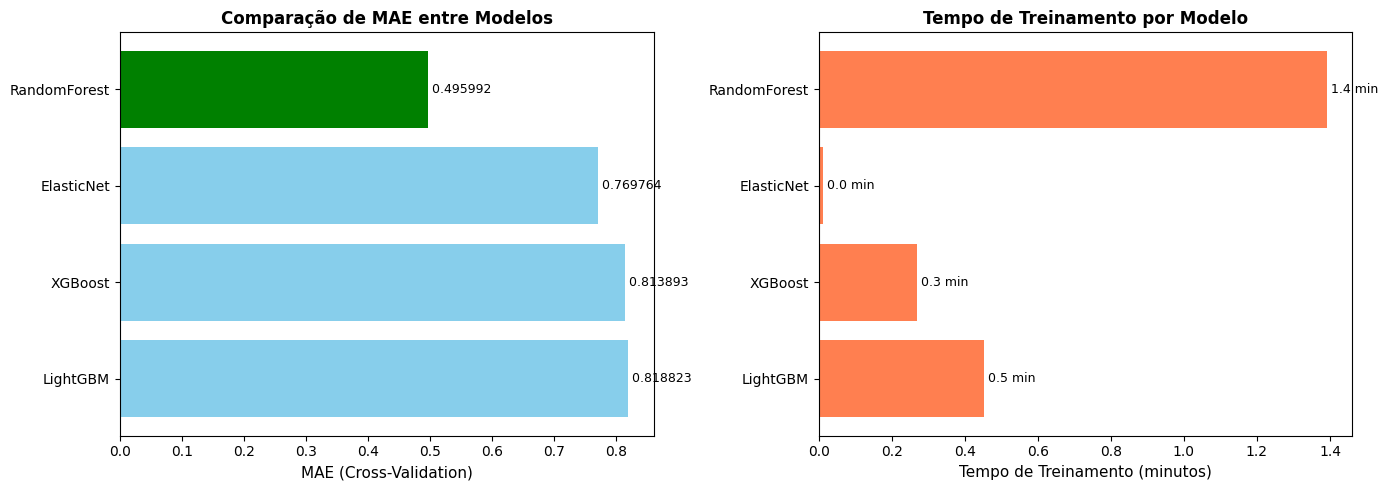

In [ ]:
# ========================================================================
# INICIALIZAR O TRAINER
# ========================================================================

trainer = ModelTrainer(
    X_train=X_train,
    y_train=y_train,
    random_state=42,
    n_splits=5,
    verbose=True
)

# ========================================================================
# TREINAR TODOS OS MODELOS DE UMA VEZ
# ========================================================================

print("\n" + "="*70)
print("🚀 TREINANDO TODOS OS MODELOS AUTOMATICAMENTE")
print("="*70)

results = trainer.train_all_models(
    n_trials_dict={
        'xgboost': 100,
        'lightgbm': 100,
        'randomforest': 80,
        'elasticnet': 60
    },
    timeout=None,  # Sem timeout global
    plot_individual=False  # Não plotar cada modelo individualmente
)

# Acessar resultados
xgb_params, xgb_model, xgb_study = results['XGBoost']
lgb_params, lgb_model, lgb_study = results['LightGBM']
rf_params, rf_model, rf_study = results['RandomForest']
elastic_params, elastic_model, elastic_study, elastic_scaler = results['ElasticNet']


🏆 COMPARAÇÃO DE TODOS OS MODELOS

Modelo          MAE (CV)     Tempo (min)  Trials     Data/Hora           
------------------------------------------------------------------------------------------
RandomForest    0.495992     1.39         80/80      2026-02-13 04:18:42 
ElasticNet      0.769764     0.01         60/60      2026-02-13 04:18:43 
XGBoost         0.813893     0.27         100/100     2026-02-13 04:16:49 
LightGBM        0.818823     0.45         100/100     2026-02-13 04:17:17 
------------------------------------------------------------------------------------------

🥇 MELHOR MODELO: RandomForest
📊 MAE (CV): 0.495992
⏱️ Tempo de treinamento: 1.39 minutos
📈 Melhoria sobre 2º lugar (ElasticNet): 35.57%



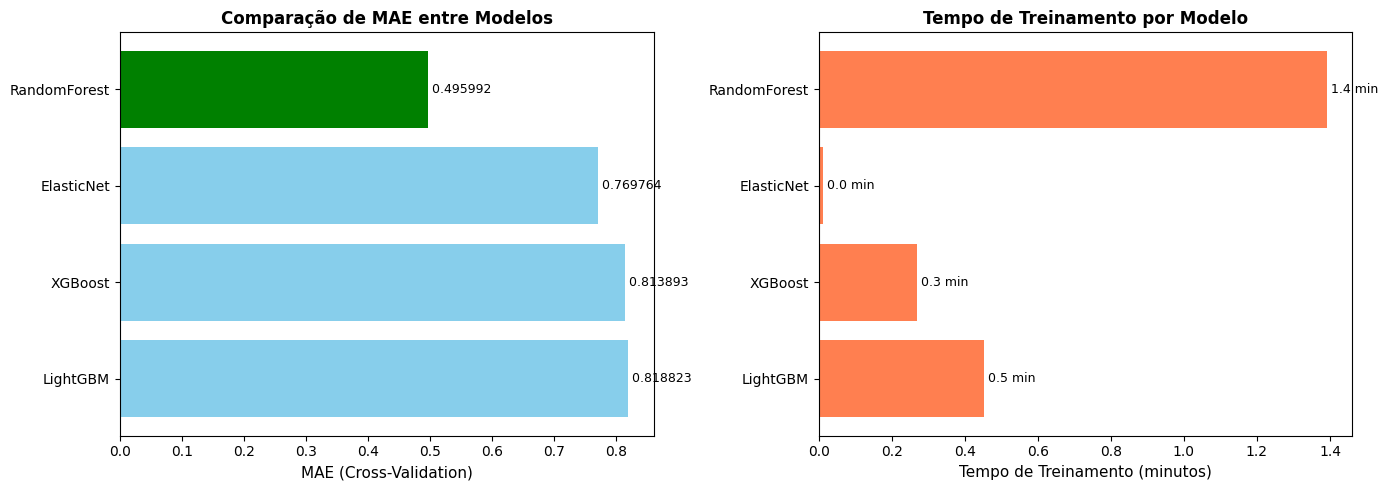


📋 Histórico completo:
     model_name                  timestamp  \
2  RandomForest 2026-02-13 04:18:42.258165   
3    ElasticNet 2026-02-13 04:18:43.373272   
0       XGBoost 2026-02-13 04:16:49.678761   
1      LightGBM 2026-02-13 04:17:17.675387   

                                         best_params  best_cv_mae  \
2  {'n_estimators': 600, 'max_depth': 10, 'max_fe...     0.495992   
3  {'alpha': 0.21004085058414657, 'l1_ratio': 0.5...     0.769764   
0  {'n_estimators': 600, 'max_depth': 8, 'learnin...     0.813893   
1  {'n_estimators': 600, 'learning_rate': 0.01186...     0.818823   

   training_time_minutes  n_trials  n_completed_trials  n_pruned_trials  
2               1.391476        80                  80                0  
3               0.010628        60                  60                0  
0               0.268342       100                 100                0  
1               0.452141       100                 100                0  

📋 RESUMO DETALHADO DE TREINAM

In [ ]:
# ========================================================================
# ANÁLISES E COMPARAÇÕES
# ========================================================================

# --- Comparar todos os modelos ---
trainer.compare_all_models()

# --- Ver histórico completo ---
history_df = trainer.get_training_history()
print("\n📋 Histórico completo:")
print(history_df)

# --- Resumo detalhado ---
trainer.print_training_summary()

# --- Obter melhor modelo ---
best_name, best_model, best_params, best_mae = trainer.get_best_model()
print(f"\n🏆 Melhor modelo: {best_name}")
print(f"📊 MAE (CV): {best_mae:.6f}")
print(f"🎯 Parâmetros: {best_params}")